# EDA Setup & Dataset Loading

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# 1.Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "Data" / "raw"

print("Project Root:", PROJECT_ROOT)
print("Data Directory:", DATA_DIR)

# 2.Verify data directory
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Data directory not found: {DATA_DIR}")

# 3.Define dataset paths

SALES_FILE = DATA_DIR / "sales.csv"
INVENTORY_FILE = DATA_DIR / "inventory.csv"
PRODUCTS_FILE = DATA_DIR / "product_master.csv"
CALENDAR_FILE = DATA_DIR / "calendar.csv"

# 4.Verify rquires files

required_files = {
    "Sales": SALES_FILE,
    "Inventory": INVENTORY_FILE,
    "Products": PRODUCTS_FILE,
    "Calendar": CALENDAR_FILE
}

missing_files = []

for name, path in required_files.items():
    if not path.exists():
        missing_files.append(f"{name}:{path}")

if missing_files:
    print("Missing required files:")
    for file in missing_files:
        print(" -",file)

    raise FileNotFoundError("One or more required files are missing. Please check the data directory.")

print("All required files are present.")


# 5.Load datasets

sales_df = pd.read_csv(SALES_FILE)
inventory_df = pd.read_csv(INVENTORY_FILE)
products_df = pd.read_csv(PRODUCTS_FILE)
calendar_df = pd.read_csv(CALENDAR_FILE)

# 6.Converts data columns

sales_df["Date"] = pd.to_datetime(
    sales_df["Date"], errors="coerce"
)

inventory_df["Snapshot_Date"] = pd.to_datetime(
    inventory_df["Snapshot_Date"], errors="coerce"
)

products_df["Launch_Date"] = pd.to_datetime(
    products_df["Launch_Date"], errors="coerce"
)

calendar_df["date"] = pd.to_datetime(
    calendar_df["date"], errors="coerce"
)

# 7.Create dataset dictionary

datasets = {
    "Sales": sales_df,
    "Inventory": inventory_df,
    "Products": products_df,
    "Calendar": calendar_df 
}

# 8.Display basic information

print("\n" + "=" * 60)
print("Foresight EDA DATASETS")
print("=" * 60)

for name, df in datasets.items():
    print(f"{name:<12} => {df.shape[0]:,} rows = {df.shape[1]:,} columns")

print("\n EDA notebook setup completed successfully....")

Project Root: d:\Zidio project\FORESIGHT Project
Data Directory: d:\Zidio project\FORESIGHT Project\Data\raw
All required files are present.

Foresight EDA DATASETS
Sales        => 36,550 rows = 6 columns
Inventory    => 4,800 rows = 8 columns
Products     => 50 rows = 8 columns
Calendar     => 731 rows = 11 columns

 EDA notebook setup completed successfully....


# Sales Dataset Overview

In [3]:
# CELL 2: SALES DATASET OVERVIEW

print("=" * 70)
print("SALES DATASET OVERVIEW")
print("=" * 70)

# Dataset shape
print(f"\nRows    : {sales_df.shape[0]:,}")
print(f"Columns : {sales_df.shape[1]}")

# Column information
print("\nColumns:")
print(sales_df.columns.tolist())

# Data types
print("\nData Types:")
print(sales_df.dtypes)

# Date range
print("\nSales Date Range:")
print(f"Start Date : {sales_df['Date'].min()}")
print(f"End Date   : {sales_df['Date'].max()}")

# Unique SKUs
print("\nUnique SKUs:")
print(f"{sales_df['SKU'].nunique():,}")

# Total units sold
print("\nTotal Units Sold:")
print(f"{sales_df['Units_Sold'].sum():,.0f}")

# Total revenue
print("\nTotal Revenue:")
print(f"{sales_df['Revenue'].sum():,.2f}")

# Average selling price
print("\nAverage Price:")
print(f"{sales_df['Price'].mean():,.2f}")

# Preview
print("\nFirst 5 Records:")
display(sales_df.head())

SALES DATASET OVERVIEW

Rows    : 36,550
Columns : 6

Columns:
['Date', 'SKU', 'Units_Sold', 'Revenue', 'Price', 'Promotion']

Data Types:
Date          datetime64[us]
SKU                      str
Units_Sold             int64
Revenue              float64
Price                float64
Promotion              int64
dtype: object

Sales Date Range:
Start Date : 2024-01-01 00:00:00
End Date   : 2025-12-31 00:00:00

Unique SKUs:
50

Total Units Sold:
511,810

Total Revenue:
3,096,056,707.22

Average Price:
5,892.66

First 5 Records:


,Date,SKU,Units_Sold,Revenue,Price,Promotion
0,2024-01-01,SKU001,5,18320.25,3664.05,0
1,2024-01-01,SKU002,15,57085.35,3805.69,0
2,2024-01-01,SKU003,5,40391.15,8078.23,0
3,2024-01-01,SKU004,5,34307.85,6861.57,0
4,2024-01-01,SKU005,12,113918.64,9493.22,0


# DAILY SALES TRENDS

DAILY SALES TREND

Number of days: 731
Average daily units sold: 700.15
Minimum daily units sold: 484
Maximum daily units sold: 1,145


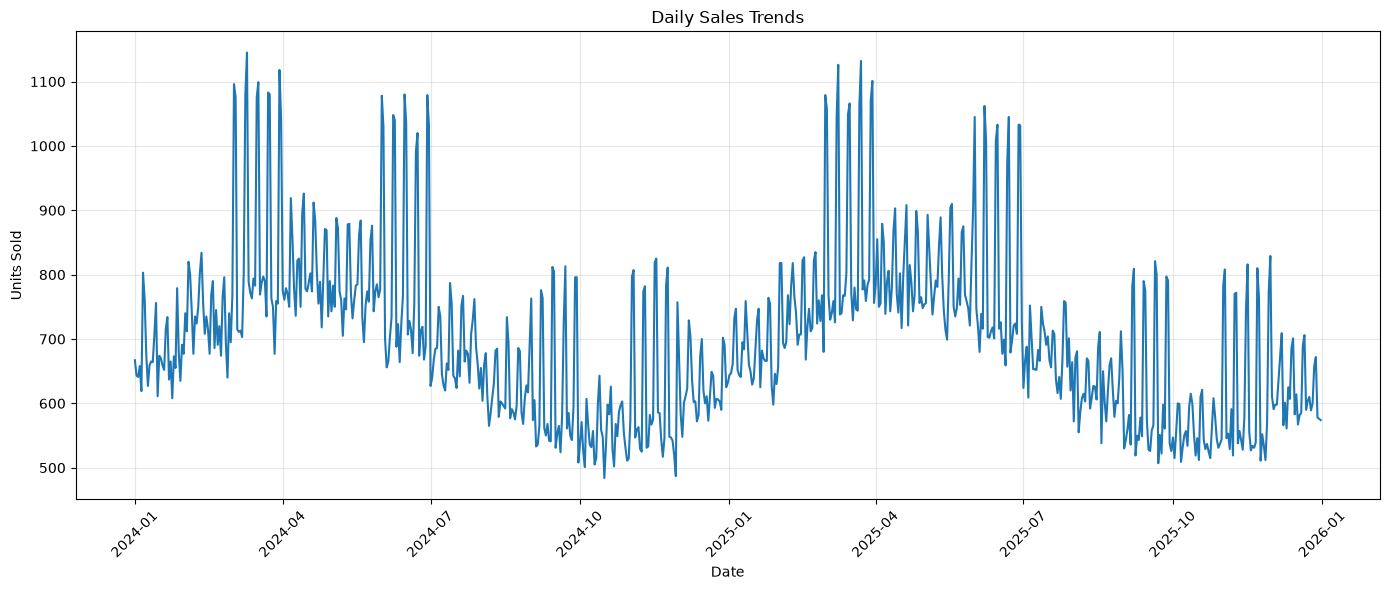

In [4]:
# CELL 3: DAILY SALES TREND

# Aggregate total units sold by date
daily_sales = (
    sales_df.groupby("Date", as_index=False)["Units_Sold"].sum().sort_values("Date")
)

#Display summary
print("=" * 70)
print("DAILY SALES TREND")
print("=" * 70)

print(f"\nNumber of days: {len(daily_sales):,}")
print(f"Average daily units sold: {daily_sales['Units_Sold'].mean():,.2f}")
print(f"Minimum daily units sold: {daily_sales['Units_Sold'].min():,.0f}")
print(f"Maximum daily units sold: {daily_sales['Units_Sold'].max():,.0f}")

#Plot
plt.figure(figsize=(14,6))

plt.plot(daily_sales["Date"],
         daily_sales["Units_Sold"],
         linewidth=1.5
         )

plt.title("Daily Sales Trends")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# Monthly Sales Trend

MONTHLY SALES TREND

Number of months: 24
Average monthly units sold: 21,325.42
Minimum monthly units sold: 17,173
Maximum monthly units sold: 26,791

Monthly Sales:


,Date,Units_Sold
0,2024-01-01,20961
1,2024-02-01,21333
2,2024-03-01,26791
3,2024-04-01,24177
4,2024-05-01,24402
5,2024-06-01,24506
6,2024-07-01,21118
7,2024-08-01,19351
8,2024-09-01,18723
9,2024-10-01,17173


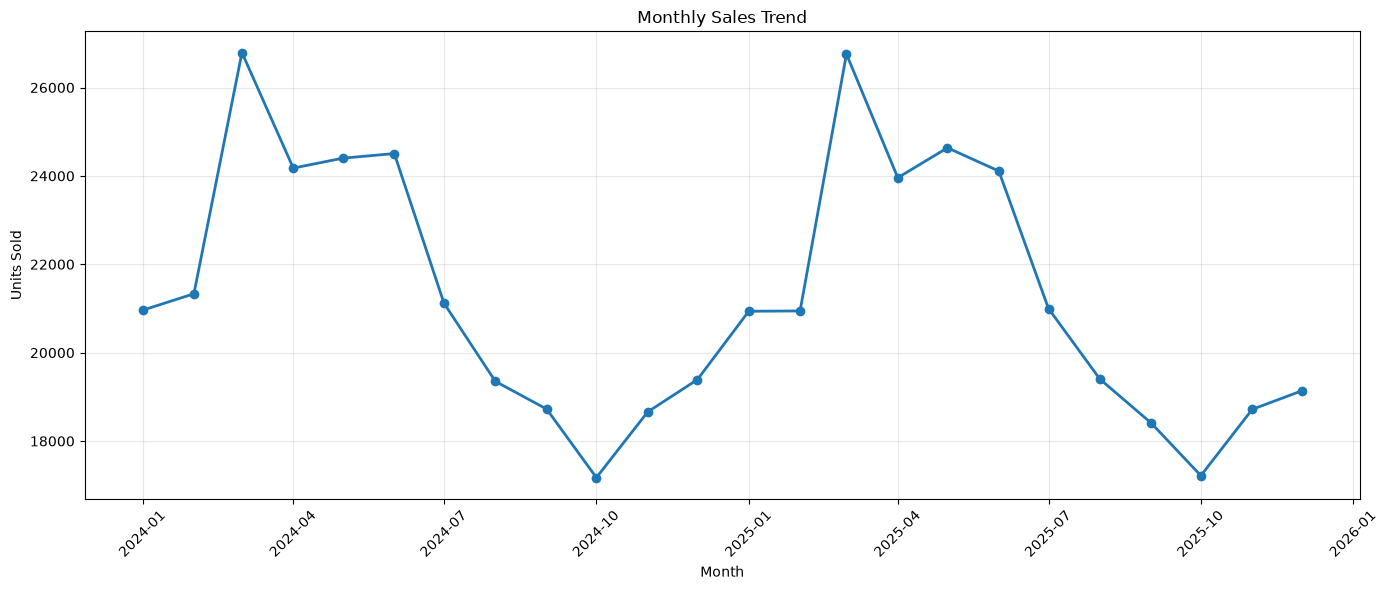

In [5]:
# CELL 4: MONTHLY SALES TREND

# Create monthly sales aggregation
monthly_sales = (
    sales_df
    .set_index("Date")
    .resample("MS")["Units_Sold"]
    .sum()
    .reset_index()
)

# Display summary
print("=" * 70)
print("MONTHLY SALES TREND")
print("=" * 70)

print(f"\nNumber of months: {len(monthly_sales):,}")
print(
    f"Average monthly units sold: "
    f"{monthly_sales['Units_Sold'].mean():,.2f}"
)
print(
    f"Minimum monthly units sold: "
    f"{monthly_sales['Units_Sold'].min():,.0f}"
)
print(
    f"Maximum monthly units sold: "
    f"{monthly_sales['Units_Sold'].max():,.0f}"
)

print("\nMonthly Sales:")
display(monthly_sales.head(12))

# Plot
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Units_Sold"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# Revenue Trend Analysis

MONTHLY REVENUE TREND

Number of months: 24
Total Revenue: 3,096,056,707.22
Average Monthly Revenue: 129,002,362.80
Minimum Monthly Revenue: 104,018,010.45
Maximum Monthly Revenue: 161,709,797.17

Monthly Revenue:


,Date,Revenue
0,2024-01-01,1.271089e+08
1,2024-02-01,1.288302e+08
2,2024-03-01,1.617098e+08
3,2024-04-01,1.465031e+08
4,2024-05-01,1.476652e+08
5,2024-06-01,1.483153e+08
6,2024-07-01,1.272197e+08
7,2024-08-01,1.177830e+08
8,2024-09-01,1.131929e+08
9,2024-10-01,1.040180e+08


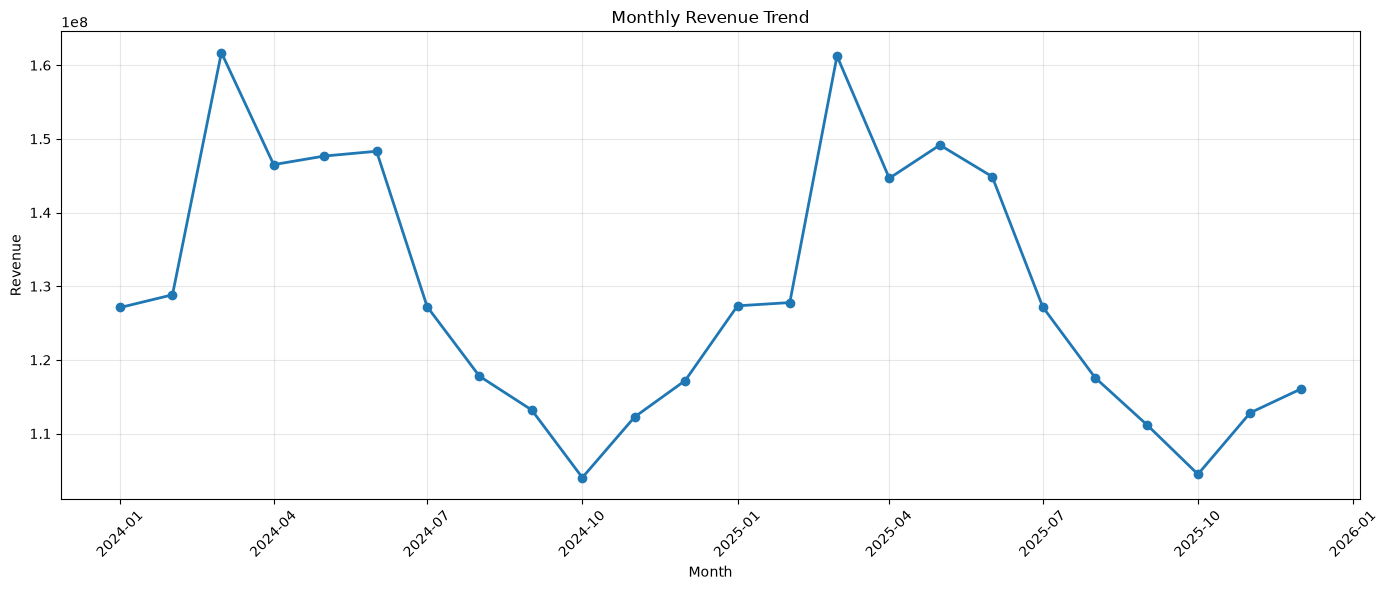

In [6]:
# CELL 5: REVENUE TREND ANALYSIS

# Aggregate revenue by month
monthly_revenue = (
    sales_df
    .set_index("Date")
    .resample("MS")["Revenue"]
    .sum()
    .reset_index()
)

# Display summary
print("=" * 70)
print("MONTHLY REVENUE TREND")
print("=" * 70)

print(f"\nNumber of months: {len(monthly_revenue):,}")

print(
    f"Total Revenue: "
    f"{monthly_revenue['Revenue'].sum():,.2f}"
)

print(
    f"Average Monthly Revenue: "
    f"{monthly_revenue['Revenue'].mean():,.2f}"
)

print(
    f"Minimum Monthly Revenue: "
    f"{monthly_revenue['Revenue'].min():,.2f}"
)

print(
    f"Maximum Monthly Revenue: "
    f"{monthly_revenue['Revenue'].max():,.2f}"
)

# Display monthly revenue
print("\nMonthly Revenue:")
display(monthly_revenue.head(12))

# Plot revenue trend
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["Date"],
    monthly_revenue["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# Top 10 SKUs by Units Sold.

TOP 10 SKUs BY UNITS SOLD


,SKU,Units_Sold
11,SKU012,19067
44,SKU045,18612
17,SKU018,18450
48,SKU049,18373
36,SKU037,18155
6,SKU007,18129
26,SKU027,17717
41,SKU042,16616
25,SKU026,16535
42,SKU043,16276


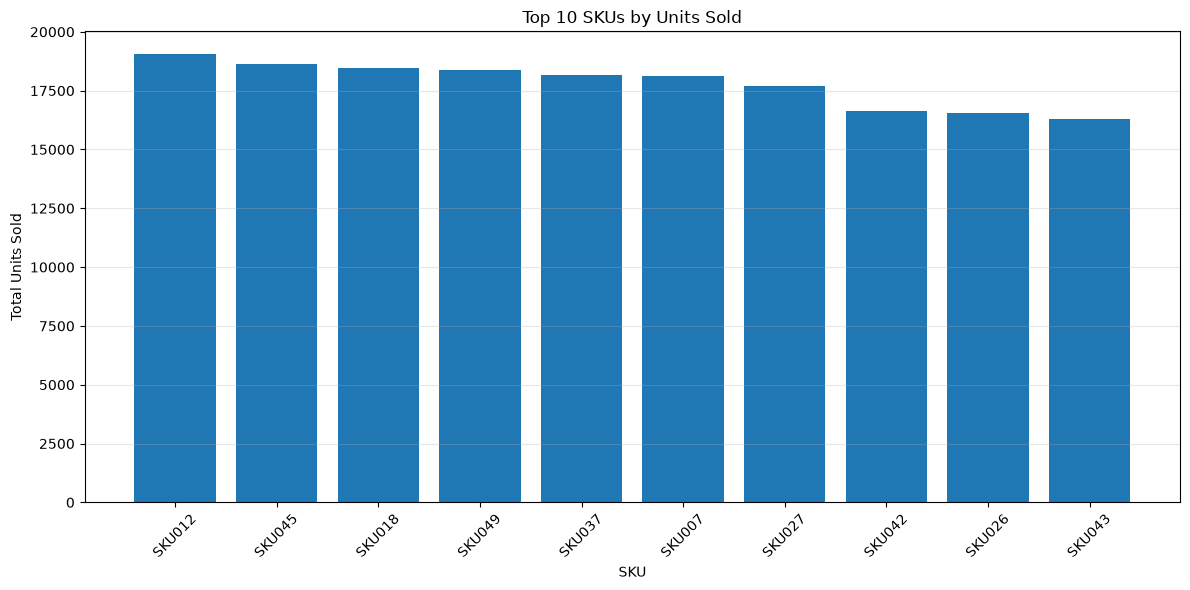

In [7]:
# CELL 6: TOP 10 SKUs BY UNITS SOLD

# Aggregate units sold by SKU
top_skus = (
    sales_df
    .groupby("SKU", as_index=False)["Units_Sold"]
    .sum()
    .sort_values("Units_Sold", ascending=False)
    .head(10)
)

# Display results
print("=" * 70)
print("TOP 10 SKUs BY UNITS SOLD")
print("=" * 70)

display(top_skus)

# Plot
plt.figure(figsize=(12, 6))

plt.bar(
    top_skus["SKU"].astype(str),
    top_skus["Units_Sold"]
)

plt.title("Top 10 SKUs by Units Sold")
plt.xlabel("SKU")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

# Bottom 10 SKUs by Units Sold

BOTTOM 10 SKUs BY UNITS SOLD


,SKU,Units_Sold
10,SKU011,1951
24,SKU025,1976
38,SKU039,2300
14,SKU015,2994
3,SKU004,3380
29,SKU030,3493
35,SKU036,3508
27,SKU028,4101
2,SKU003,4214
49,SKU050,4537


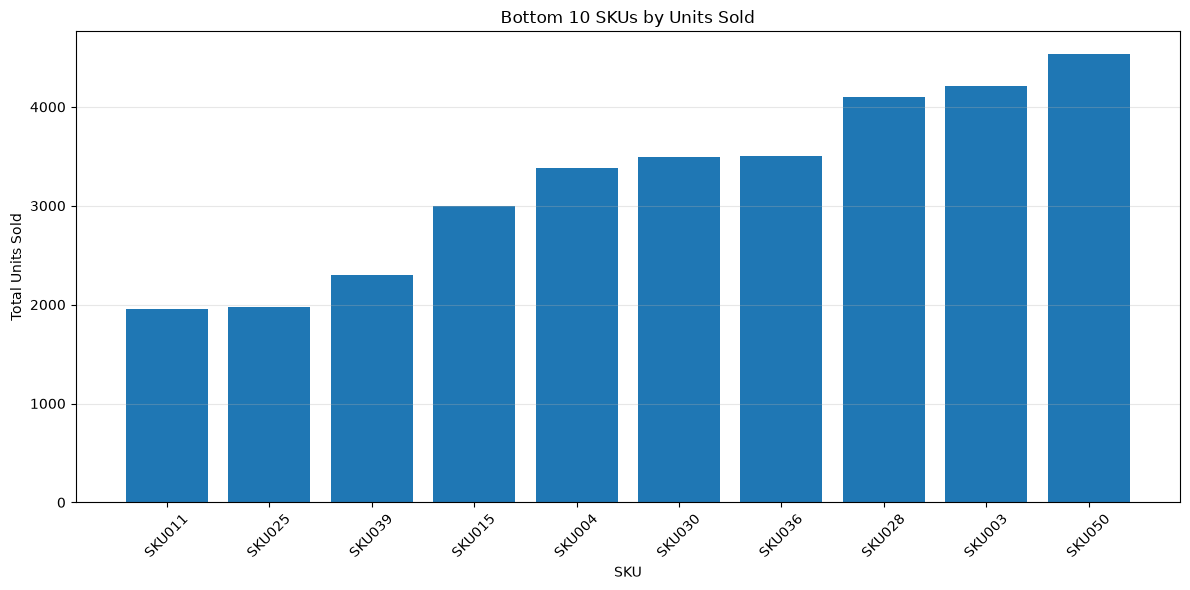

In [8]:
# CELL 7: BOTTOM 10 SKUs BY UNITS SOLD

# Aggregate units sold by SKU
bottom_skus = (
    sales_df
    .groupby("SKU", as_index=False)["Units_Sold"]
    .sum()
    .sort_values("Units_Sold", ascending=True)
    .head(10)
)

# Display results
print("=" * 70)
print("BOTTOM 10 SKUs BY UNITS SOLD")
print("=" * 70)

display(bottom_skus)

# Plot
plt.figure(figsize=(12, 6))

plt.bar(
    bottom_skus["SKU"].astype(str),
    bottom_skus["Units_Sold"]
)

plt.title("Bottom 10 SKUs by Units Sold")
plt.xlabel("SKU")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

# Category-wise Sales Analysis.

CATEGORY-WISE SALES ANALYSIS

Sales records without category: 0

Category-wise Sales:


,Category,Units_Sold,Revenue,Average_Price,SKU_Count
1,Home Decor,132570,8.884681e+08,6478.716,10
3,Lighting,102431,4.587362e+08,4897.312,10
2,Kitchen,101144,5.635346e+08,5178.731,10
4,Storage,93367,5.819274e+08,6313.811,10
0,Furniture,82298,6.033905e+08,6594.749,10


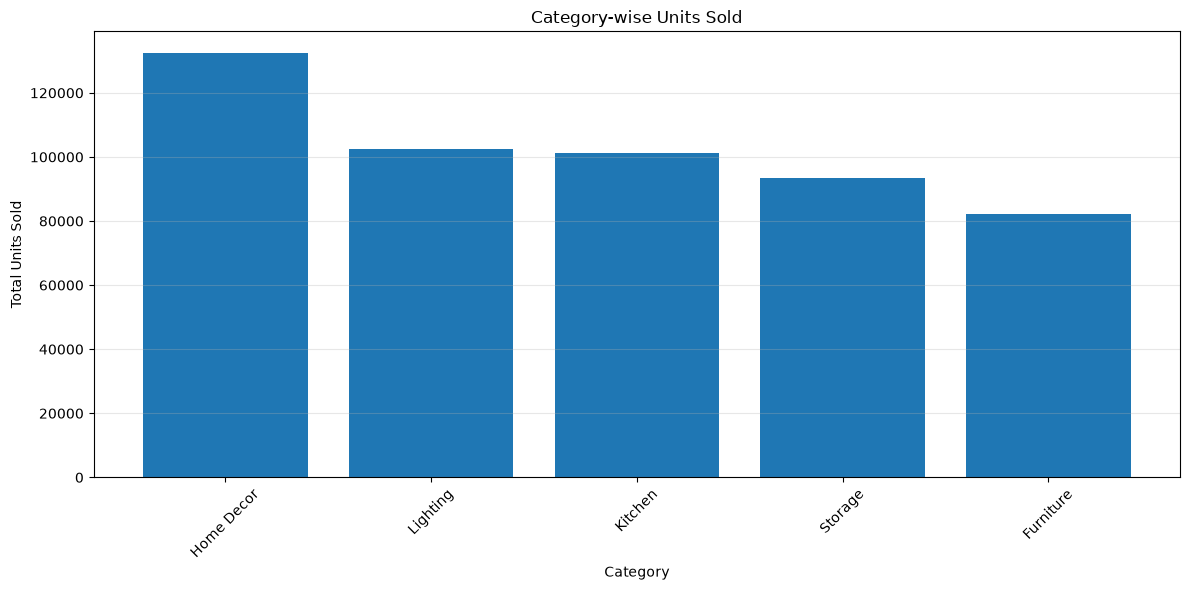

In [9]:

# CELL 8: CATEGORY-WISE SALES ANALYSIS


# Join Sales data with Product Master using SKU
sales_with_products = sales_df.merge(
    products_df[["SKU", "Product_Name", "Category", "Subcategory"]],
    on="SKU",
    how="left"
)

print("=" * 70)
print("CATEGORY-WISE SALES ANALYSIS")
print("=" * 70)

# Check unmatched SKUs
unmatched = sales_with_products["Category"].isna().sum()

print(f"\nSales records without category: {unmatched:,}")

# Aggregate sales by category
category_sales = (
    sales_with_products
    .groupby("Category", as_index=False)
    .agg(
        Units_Sold=("Units_Sold", "sum"),
        Revenue=("Revenue", "sum"),
        Average_Price=("Price", "mean"),
        SKU_Count=("SKU", "nunique")
    )
    .sort_values("Units_Sold", ascending=False)
)

# Display results
print("\nCategory-wise Sales:")
display(category_sales)

# Plot units sold by category
plt.figure(figsize=(12, 6))

plt.bar(
    category_sales["Category"].astype(str),
    category_sales["Units_Sold"]
)

plt.title("Category-wise Units Sold")
plt.xlabel("Category")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

# Subcategory-wise Sales Analysis

SUBCATEGORY-WISE SALES ANALYSIS

Subcategory-wise Sales:


,Subcategory,Units_Sold,Revenue,Average_Price,SKU_Count
0,Cabinet,75233,4.676183e+08,6558.730,5
9,Table,57337,4.208498e+08,6398.702,5
3,Cushion,54833,2.980239e+08,5511.304,5
5,Organizer,51836,3.217665e+08,6228.302,5
4,Lamp,51340,4.692592e+08,9162.064,5
2,Cookware,50595,1.369696e+08,3566.322,5
6,Rug,46311,2.655107e+08,4846.158,5
8,Sofa,42027,1.126683e+08,3465.558,5
7,Shelf,41733,3.101227e+08,6814.988,5
1,Chair,40565,2.932678e+08,6374.510,5


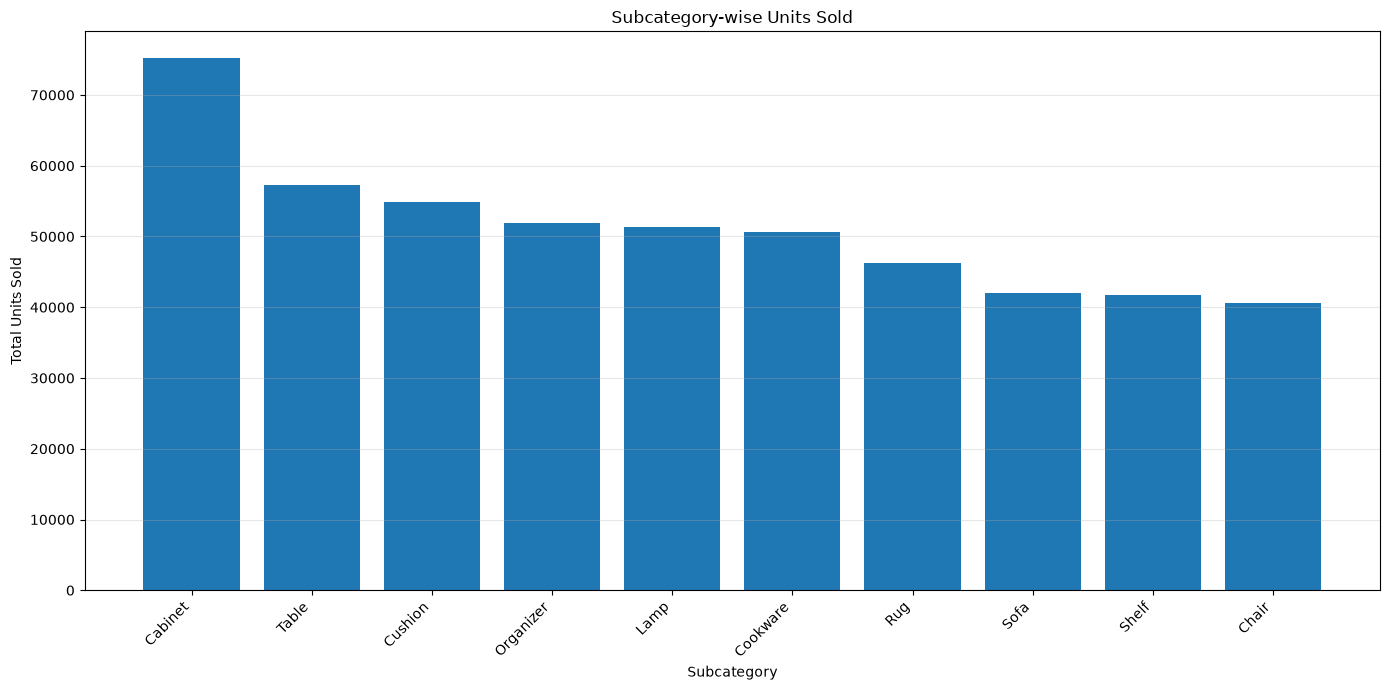

In [10]:
# CELL 9: SUBCATEGORY-WISE SALES ANALYSIS

print("=" * 70)
print("SUBCATEGORY-WISE SALES ANALYSIS")
print("=" * 70)

# Aggregate sales by subcategory
subcategory_sales = (
    sales_with_products
    .groupby("Subcategory", as_index=False)
    .agg(
        Units_Sold=("Units_Sold", "sum"),
        Revenue=("Revenue", "sum"),
        Average_Price=("Price", "mean"),
        SKU_Count=("SKU", "nunique")
    )
    .sort_values("Units_Sold", ascending=False)
)

# Display results
print("\nSubcategory-wise Sales:")
display(subcategory_sales)

# Plot
plt.figure(figsize=(14, 7))

plt.bar(
    subcategory_sales["Subcategory"].astype(str),
    subcategory_sales["Units_Sold"]
)

plt.title("Subcategory-wise Units Sold")
plt.xlabel("Subcategory")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

# Promotion vs Non-Promotion Sales Analysis

PROMOTION VS NON-PROMOTION SALES ANALYSIS

Promotion values:
Promotion
0    32800
1     3750
Name: count, dtype: int64

Promotion Analysis:


,Promotion_Status,Units_Sold,Revenue,Average_Price,SKU_Count,Average_Units_Per_Record
0,No Promotion,442011,2.674843e+09,5892.6638,50,13.475945
1,Promotion,69799,4.212141e+08,5892.6638,50,18.613067


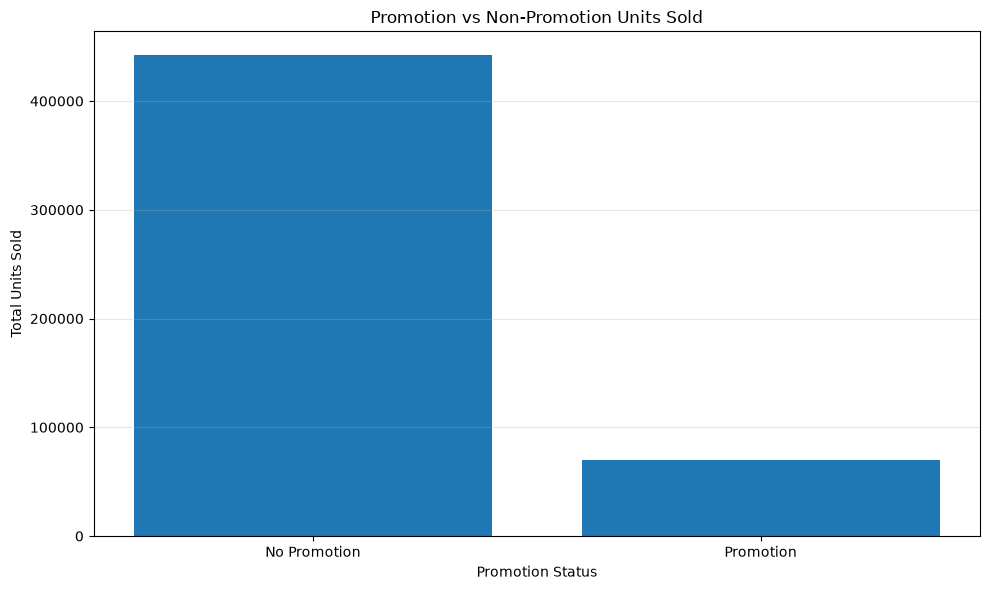

In [11]:
# CELL 10: PROMOTION VS NON-PROMOTION SALES ANALYSIS

print("=" * 70)
print("PROMOTION VS NON-PROMOTION SALES ANALYSIS")
print("=" * 70)

# Check promotion values
print("\nPromotion values:")
print(sales_df["Promotion"].value_counts(dropna=False))

# Create promotion groups
sales_promo = sales_df.copy()

sales_promo["Promotion_Status"] = (
    sales_promo["Promotion"]
    .fillna(0)
    .astype(int)
    .map({
        0: "No Promotion",
        1: "Promotion"
    })
)

# Aggregate sales
promotion_analysis = (
    sales_promo
    .groupby("Promotion_Status", as_index=False)
    .agg(
        Units_Sold=("Units_Sold", "sum"),
        Revenue=("Revenue", "sum"),
        Average_Price=("Price", "mean"),
        SKU_Count=("SKU", "nunique")
    )
)

# Average values per record
promotion_analysis["Average_Units_Per_Record"] = (
    promotion_analysis["Units_Sold"]
    / sales_promo["Promotion_Status"]
        .value_counts()
        .reindex(promotion_analysis["Promotion_Status"])
        .values
)

print("\nPromotion Analysis:")
display(promotion_analysis)

# Plot units sold
plt.figure(figsize=(10, 6))

plt.bar(
    promotion_analysis["Promotion_Status"],
    promotion_analysis["Units_Sold"]
)

plt.title("Promotion vs Non-Promotion Units Sold")
plt.xlabel("Promotion Status")
plt.ylabel("Total Units Sold")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

# Monthly & Seasonal Demand Analysis

MONTHLY & SEASONAL DEMAND ANALYSIS

Monthly Demand:


,Year,Month,Month_Name,Units_Sold,Revenue
0,2024,1,Jan,20961,1.271089e+08
1,2024,2,Feb,21333,1.288302e+08
2,2024,3,Mar,26791,1.617098e+08
3,2024,4,Apr,24177,1.465031e+08
4,2024,5,May,24402,1.476652e+08
5,2024,6,Jun,24506,1.483153e+08
6,2024,7,Jul,21118,1.272197e+08
7,2024,8,Aug,19351,1.177830e+08
8,2024,9,Sep,18723,1.131929e+08
9,2024,10,Oct,17173,1.040180e+08


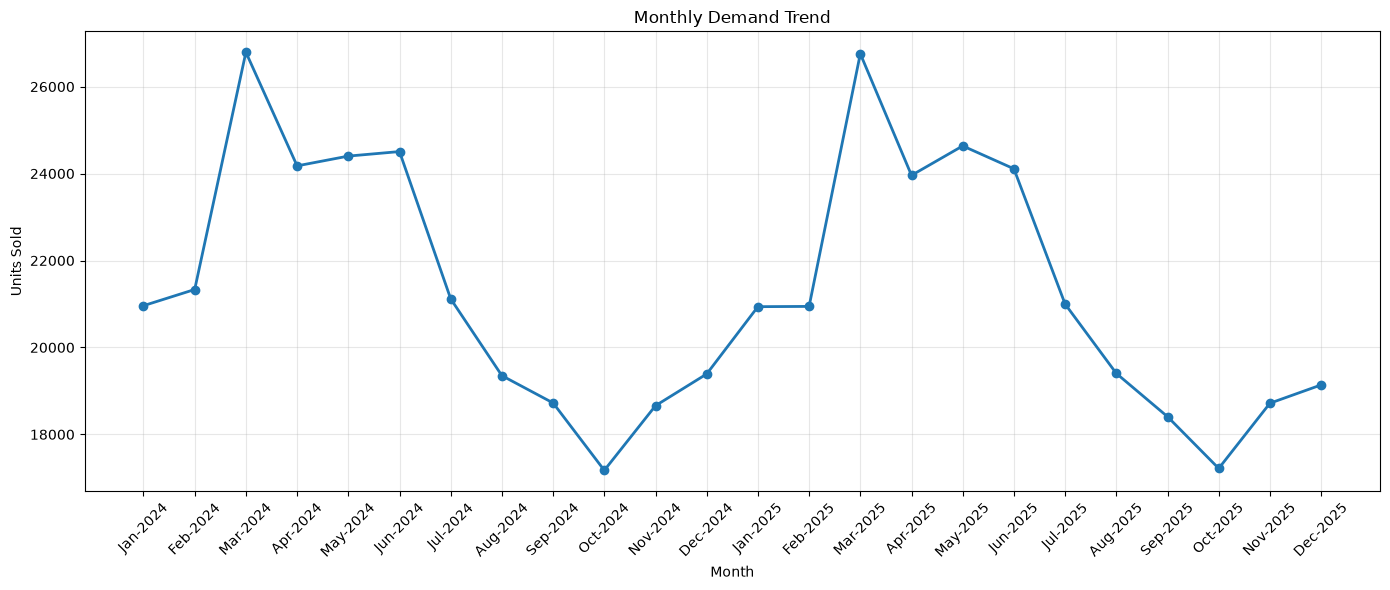


Seasonal Demand:


,season,Units_Sold,Revenue,Average_Daily_Units
4,Winter,122704,7.442873e+08,13.558453
1,Monsoon,118001,7.140896e+08,12.826196
2,Spring,101684,6.141112e+08,16.669508
3,Summer,97654,5.900151e+08,16.008852
0,Autumn,71767,4.335536e+08,11.765082


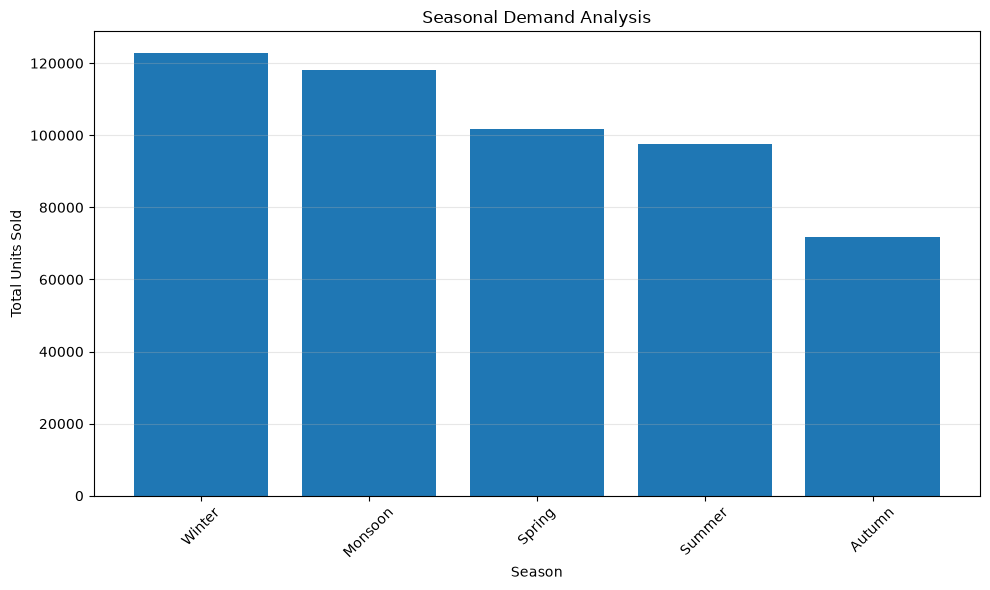

In [12]:
# CELL 11: MONTHLY & SEASONAL DEMAND ANALYSIS

print("=" * 70)
print("MONTHLY & SEASONAL DEMAND ANALYSIS")
print("=" * 70)

# 1. Add month information to sales data

sales_monthly = sales_df.copy()

sales_monthly["Year"] = sales_monthly["Date"].dt.year
sales_monthly["Month"] = sales_monthly["Date"].dt.month
sales_monthly["Month_Name"] = sales_monthly["Date"].dt.strftime("%b")

# 2. Monthly demand

monthly_demand = (
    sales_monthly
    .groupby(["Year", "Month", "Month_Name"], as_index=False)
    .agg(
        Units_Sold=("Units_Sold", "sum"),
        Revenue=("Revenue", "sum")
    )
    .sort_values(["Year", "Month"])
)

print("\nMonthly Demand:")
display(monthly_demand)

# 3. Plot monthly demand

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_demand["Month_Name"] + "-" + monthly_demand["Year"].astype(str),
    monthly_demand["Units_Sold"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 4. Join Calendar data to identify seasons
# ------------------------------------------------------------

sales_seasonal = sales_df.merge(
    calendar_df[["date", "season"]],
    left_on="Date",
    right_on="date",
    how="left"
)

# ------------------------------------------------------------
# 5. Seasonal demand analysis
# ------------------------------------------------------------

seasonal_demand = (
    sales_seasonal
    .groupby("season", as_index=False)
    .agg(
        Units_Sold=("Units_Sold", "sum"),
        Revenue=("Revenue", "sum"),
        Average_Daily_Units=("Units_Sold", "mean")
    )
    .sort_values("Units_Sold", ascending=False)
)

print("\nSeasonal Demand:")
display(seasonal_demand)

# ------------------------------------------------------------
# 6. Plot seasonal demand
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    seasonal_demand["season"].astype(str),
    seasonal_demand["Units_Sold"]
)

plt.title("Seasonal Demand Analysis")
plt.xlabel("Season")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

# Inventory Analysis & Stock Levels

INVENTORY ANALYSIS & STOCK LEVELS

Inventory Dataset:
Rows    : 4,800
Columns : 8

Inventory Summary Statistics:


,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Inventory_Value
count,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4.800000e+03
mean,304.143333,213.093750,8.438958,83.152708,211.745417,1.304166e+06
std,280.890448,244.456955,3.488024,70.256045,179.905422,1.741551e+06
min,2.000000,0.000000,3.000000,5.000000,10.000000,2.444200e+03
25%,109.000000,49.000000,5.000000,35.000000,87.000000,2.521855e+05
50%,229.000000,135.000000,8.000000,67.000000,169.000000,6.837389e+05
75%,418.000000,292.000000,11.250000,112.000000,286.000000,1.720023e+06
max,2585.000000,3060.000000,14.000000,746.000000,1661.000000,2.027987e+07



Stock Status:


,Stock_Status,SKU_Count
0,Healthy,3397
1,Reorder Required,1275
2,Below Safety Stock,128



Inventory Metrics:
Total Current Stock : 1,459,888
Total On Order      : 1,022,850
Total Inventory Value : 6,259,999,045.14
Average Lead Time   : 8.44 days


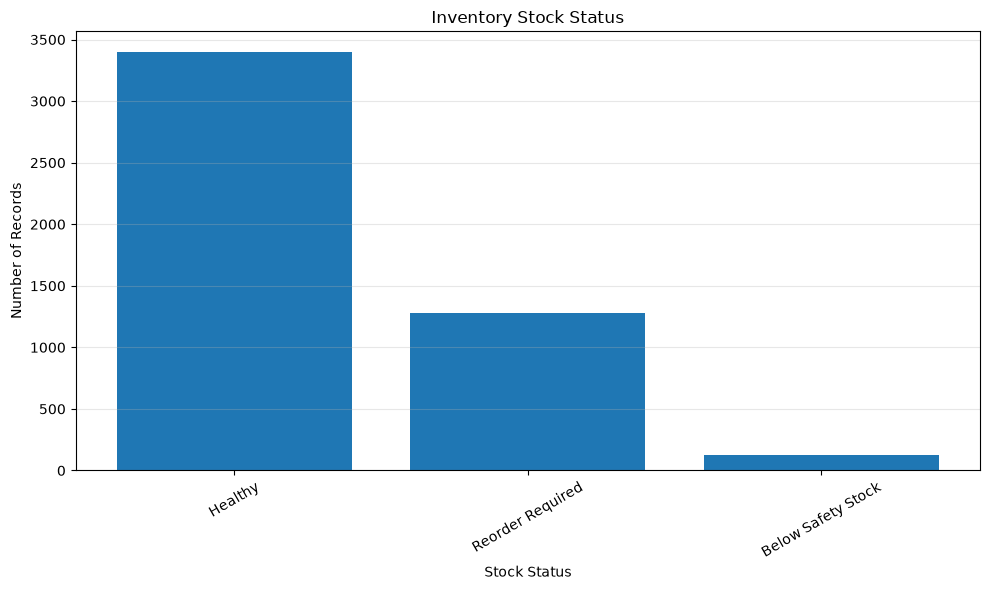

In [13]:
# CELL 12: INVENTORY ANALYSIS & STOCK LEVELS

print("=" * 70)
print("INVENTORY ANALYSIS & STOCK LEVELS")
print("=" * 70)

# 1. Basic inventory summary

print("\nInventory Dataset:")
print(f"Rows    : {inventory_df.shape[0]:,}")
print(f"Columns : {inventory_df.shape[1]}")

print("\nInventory Summary Statistics:")
display(
    inventory_df[
        [
            "Current_Stock",
            "On_Order",
            "Lead_Time_Days",
            "Safety_Stock",
            "Reorder_Point",
            "Inventory_Value"
        ]
    ].describe()
)

# 2. Calculate inventory status

inventory_analysis = inventory_df.copy()

inventory_analysis["Available_Stock"] = (
    inventory_analysis["Current_Stock"]
    + inventory_analysis["On_Order"]
)

inventory_analysis["Stock_Status"] = np.select(
    [
        inventory_analysis["Current_Stock"] <= 0,
        inventory_analysis["Current_Stock"] < inventory_analysis["Safety_Stock"],
        inventory_analysis["Current_Stock"] <= inventory_analysis["Reorder_Point"],
        inventory_analysis["Current_Stock"] > inventory_analysis["Reorder_Point"]
    ],
    [
        "Stockout",
        "Below Safety Stock",
        "Reorder Required",
        "Healthy"
    ],
    default="Unknown"
)

# 3. Stock status summary

print("\nStock Status:")
display(
    inventory_analysis["Stock_Status"]
    .value_counts()
    .rename_axis("Stock_Status")
    .reset_index(name="SKU_Count")
)

# 4. Total inventory metrics

print("\nInventory Metrics:")
print(
    f"Total Current Stock : "
    f"{inventory_analysis['Current_Stock'].sum():,.0f}"
)

print(
    f"Total On Order      : "
    f"{inventory_analysis['On_Order'].sum():,.0f}"
)

print(
    f"Total Inventory Value : "
    f"{inventory_analysis['Inventory_Value'].sum():,.2f}"
)

print(
    f"Average Lead Time   : "
    f"{inventory_analysis['Lead_Time_Days'].mean():,.2f} days"
)

# 5. Plot stock status

stock_status_counts = (
    inventory_analysis["Stock_Status"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    stock_status_counts.index.astype(str),
    stock_status_counts.values
)

plt.title("Inventory Stock Status")
plt.xlabel("Stock Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

# Inventory vs Demand Analysis

INVENTORY VS DEMAND ANALYSIS

Highest Demand Risk SKUs:


,SKU,Current_Stock,On_Order,Average_Daily_Demand,Lead_Time_Days,Safety_Stock,Reorder_Point,Days_of_Stock,Demand_Risk
28,SKU029,5,17,15.772914,13,5,18,0.316999,High Stockout Risk
12,SKU013,5,19,14.075239,4,6,10,0.355234,High Stockout Risk
18,SKU019,7,32,16.146375,12,5,17,0.433534,High Stockout Risk
48,SKU049,11,1,25.134063,11,5,16,0.437653,High Stockout Risk
6,SKU007,12,2,24.800274,3,7,10,0.483866,High Stockout Risk
32,SKU033,10,17,18.090287,4,5,10,0.552783,High Stockout Risk
25,SKU026,14,33,22.619699,11,7,18,0.618930,High Stockout Risk
44,SKU045,16,6,25.461012,3,7,10,0.628412,High Stockout Risk
41,SKU042,15,26,22.730506,9,6,15,0.659906,High Stockout Risk
42,SKU043,17,2,22.265390,13,5,18,0.763517,High Stockout Risk



Demand Risk Summary:


,Demand_Risk,SKU_Count
0,Healthy,3286
1,Reorder Required,1126
2,High Stockout Risk,274
3,Low Stock Risk,114


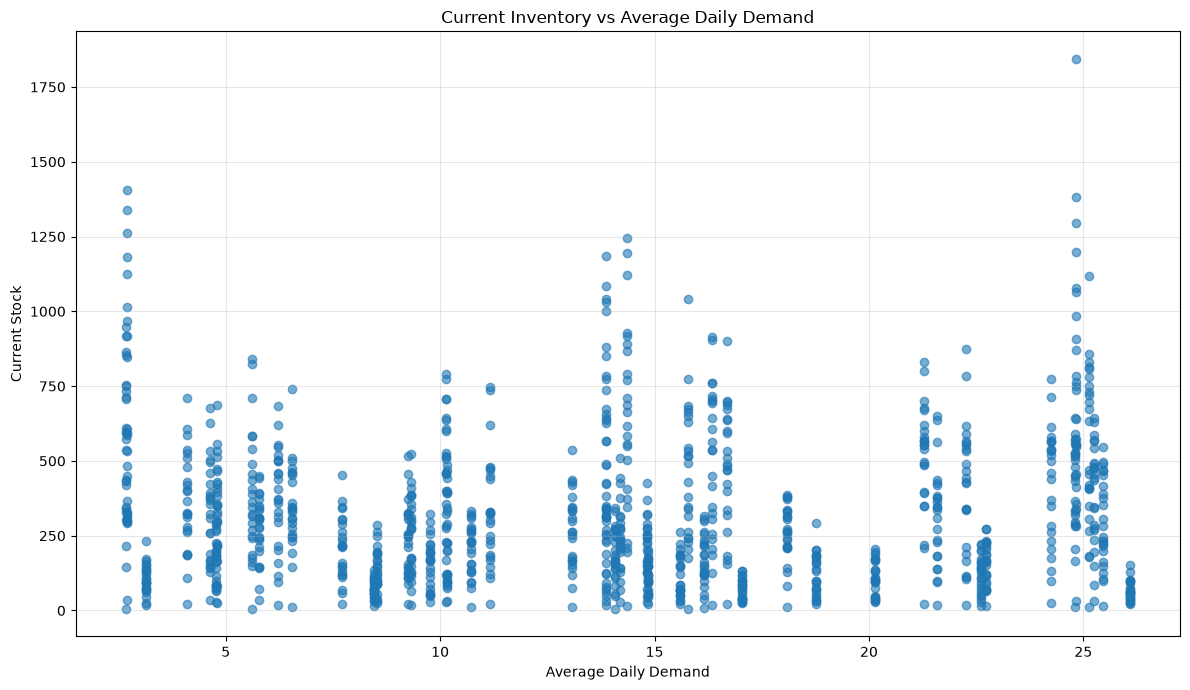

In [14]:
# CELL 13: INVENTORY VS DEMAND ANALYSIS

print("=" * 70)
print("INVENTORY VS DEMAND ANALYSIS")
print("=" * 70)

# 1. Calculate average daily demand per SKU

sku_demand = (
    sales_df
    .groupby("SKU", as_index=False)
    .agg(
        Total_Units_Sold=("Units_Sold", "sum"),
        Average_Daily_Demand=("Units_Sold", "mean"),
        Sales_Days=("Date", "nunique")
    )
)

# 2. Merge demand with inventory

inventory_demand = inventory_analysis.merge(
    sku_demand,
    on="SKU",
    how="left"
)

# 3. Calculate estimated days of stock

inventory_demand["Days_of_Stock"] = np.where(
    inventory_demand["Average_Daily_Demand"] > 0,
    inventory_demand["Current_Stock"]
    / inventory_demand["Average_Daily_Demand"],
    np.nan
)

# 4. Compare stock with reorder point

inventory_demand["Demand_Risk"] = np.select(
    [
        inventory_demand["Current_Stock"] <= 0,
        inventory_demand["Days_of_Stock"] < inventory_demand["Lead_Time_Days"],
        inventory_demand["Current_Stock"] < inventory_demand["Safety_Stock"],
        inventory_demand["Current_Stock"] <= inventory_demand["Reorder_Point"]
    ],
    [
        "Stockout Risk",
        "High Stockout Risk",
        "Low Stock Risk",
        "Reorder Required"
    ],
    default="Healthy"
)

# 5. Display highest-risk SKUs

print("\nHighest Demand Risk SKUs:")

risk_skus = (
    inventory_demand[
        inventory_demand["Demand_Risk"] != "Healthy"
    ]
    [
        [
            "SKU",
            "Current_Stock",
            "On_Order",
            "Average_Daily_Demand",
            "Lead_Time_Days",
            "Safety_Stock",
            "Reorder_Point",
            "Days_of_Stock",
            "Demand_Risk"
        ]
    ]
    .sort_values("Days_of_Stock", ascending=True)
)

display(risk_skus.head(20))

# 6. Risk summary

print("\nDemand Risk Summary:")

risk_summary = (
    inventory_demand["Demand_Risk"]
    .value_counts()
    .rename_axis("Demand_Risk")
    .reset_index(name="SKU_Count")
)

display(risk_summary)

# 7. Inventory vs average daily demand

plt.figure(figsize=(12, 7))

plt.scatter(
    inventory_demand["Average_Daily_Demand"],
    inventory_demand["Current_Stock"],
    alpha=0.6
)

plt.title("Current Inventory vs Average Daily Demand")
plt.xlabel("Average Daily Demand")
plt.ylabel("Current Stock")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# Overstock Risk Analysis

OVERSTOCK RISK ANALYSIS

Top Overstock Risk SKUs:


,SKU,Current_Stock,On_Order,Average_Daily_Demand,Reorder_Point,Excess_Stock,Days_of_Stock,Inventory_Value,Overstock_Risk
1024,SKU025,1407,841,2.703146,626,781,520.504555,5488707.00,High Overstock Risk
1224,SKU025,1339,717,2.703146,571,768,495.348684,5223439.00,High Overstock Risk
624,SKU025,1263,1100,2.703146,810,453,467.233300,4926963.00,High Overstock Risk
3424,SKU025,1181,324,2.703146,407,774,436.898279,4607081.00,High Overstock Risk
4624,SKU025,1124,61,2.703146,582,542,415.811741,4384724.00,High Overstock Risk
824,SKU025,1015,185,2.703146,565,450,375.488360,3959515.00,High Overstock Risk
2424,SKU025,968,203,2.703146,295,673,358.101215,3776168.00,High Overstock Risk
1210,SKU011,946,45,2.668947,357,589,354.446950,3658267.14,High Overstock Risk
1010,SKU011,916,171,2.668947,416,500,343.206561,3542254.44,High Overstock Risk
1824,SKU025,916,356,2.703146,527,389,338.864372,3573316.00,High Overstock Risk



Overstock Risk Summary:


,Overstock_Risk,SKU_Count
0,No Sales Data,3600
1,Normal,1039
2,Moderate Overstock Risk,84
3,High Overstock Risk,77



Excess Inventory Metrics:
Total Excess Stock: 549,961
Inventory Value at Risk: 320,581,944.77


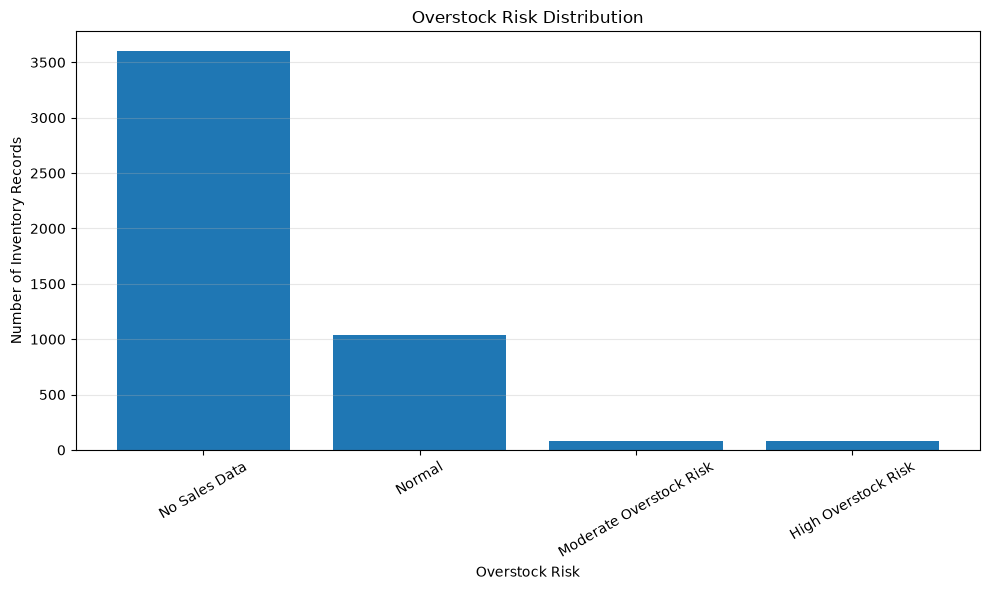

In [19]:
# CELL 14: OVERSTOCK RISK ANALYSIS

print("=" * 70)
print("OVERSTOCK RISK ANALYSIS")
print("=" * 70)

# 1. Calculate excess stock above reorder point

inventory_demand["Excess_Stock"] = (
    inventory_demand["Current_Stock"]
    - inventory_demand["Reorder_Point"]
)

# Negative excess stock is not considered overstock
inventory_demand["Excess_Stock"] = (
    inventory_demand["Excess_Stock"].clip(lower=0)
)

# 2. Calculate inventory coverage

inventory_demand["Days_of_Stock"] = np.where(
    inventory_demand["Average_Daily_Demand"] > 0,
    inventory_demand["Current_Stock"]
    / inventory_demand["Average_Daily_Demand"],
    np.nan
)

# 3. Define overstock risk

inventory_demand["Overstock_Risk"] = np.select(
    [
        inventory_demand["Average_Daily_Demand"].isna(),
        inventory_demand["Average_Daily_Demand"] <= 0,
        inventory_demand["Days_of_Stock"] > 90,
        inventory_demand["Days_of_Stock"] > 60
    ],
    [
        "No Sales Data",
        "No Demand",
        "High Overstock Risk",
        "Moderate Overstock Risk"
    ],
    default="Normal"
)

# 4. Display overstock SKUs

print("\nTop Overstock Risk SKUs:")

overstock_skus = (
    inventory_demand[
        inventory_demand["Overstock_Risk"].isin(
            ["High Overstock Risk", "Moderate Overstock Risk", "No Demand"]
        )
    ]
    [
        [
            "SKU",
            "Current_Stock",
            "On_Order",
            "Average_Daily_Demand",
            "Reorder_Point",
            "Excess_Stock",
            "Days_of_Stock",
            "Inventory_Value",
            "Overstock_Risk"
        ]
    ]
    .sort_values(
        "Days_of_Stock",
        ascending=False,
        na_position="first"
    )
)

display(overstock_skus.head(20))

# 5. Overstock risk summary

print("\nOverstock Risk Summary:")

overstock_summary = (
    inventory_demand["Overstock_Risk"]
    .value_counts()
    .rename_axis("Overstock_Risk")
    .reset_index(name="SKU_Count")
)

display(overstock_summary)

# 6. Total excess inventory

total_excess_stock = inventory_demand["Excess_Stock"].sum()

risk_categories = [
    "High Overstock Risk",
    "Moderate Overstock Risk",
    "No Demand"
]

inventory_value_at_risk = inventory_demand.loc[
    inventory_demand["Overstock_Risk"].isin(risk_categories),
    "Inventory_Value"
].sum()

print("\nExcess Inventory Metrics:")

print(f"Total Excess Stock: {total_excess_stock:,.0f}")

print(
    f"Inventory Value at Risk: "
    f"{inventory_value_at_risk:,.2f}"
)

# 7. Plot overstock risk

risk_counts = (
    inventory_demand["Overstock_Risk"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    risk_counts.index.astype(str),
    risk_counts.values
)

plt.title("Overstock Risk Distribution")
plt.xlabel("Overstock Risk")
plt.ylabel("Number of Inventory Records")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

# Combined Inventory Risk Visualization

COMBINED INVENTORY RISK ANALYSIS

Combined Inventory Risk Summary:


,Risk_Category,SKU_Count
0,Healthy,4365
1,Stockout Risk,274
2,Overstock Risk,161



Risky Inventory SKUs:


,SKU,Current_Stock,On_Order,Average_Daily_Demand,Days_of_Stock,Safety_Stock,Reorder_Point,Inventory_Value,Combined_Risk
28,SKU029,5,17,15.772914,0.316999,5,18,17080.50,Stockout Risk
12,SKU013,5,19,14.075239,0.355234,6,10,38741.00,Stockout Risk
18,SKU019,7,32,16.146375,0.433534,5,17,22770.72,Stockout Risk
48,SKU049,11,1,25.134063,0.437653,5,16,58149.41,Stockout Risk
6,SKU007,12,2,24.800274,0.483866,7,10,54576.36,Stockout Risk
32,SKU033,10,17,18.090287,0.552783,5,10,33995.00,Stockout Risk
25,SKU026,14,33,22.619699,0.618930,7,18,86502.36,Stockout Risk
44,SKU045,16,6,25.461012,0.628412,7,10,29093.12,Stockout Risk
41,SKU042,15,26,22.730506,0.659906,6,15,116416.80,Stockout Risk
42,SKU043,17,2,22.265390,0.763517,5,18,63453.35,Stockout Risk


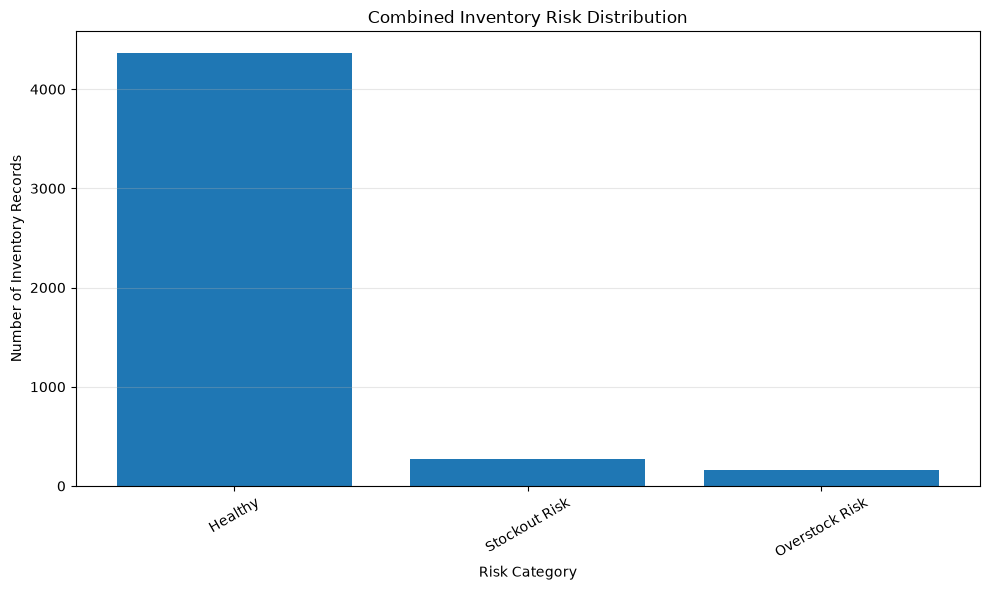

In [20]:
# CELL 15: COMBINED INVENTORY RISK VISUALIZATION

print("=" * 70)
print("COMBINED INVENTORY RISK ANALYSIS")
print("=" * 70)

# 1. Create combined risk category

inventory_demand["Combined_Risk"] = np.select(
    [
        inventory_demand["Demand_Risk"].isin(
            ["Stockout Risk", "High Stockout Risk"]
        ),
        inventory_demand["Overstock_Risk"].isin(
            ["High Overstock Risk", "Moderate Overstock Risk", "No Demand"]
        )
    ],
    [
        "Stockout Risk",
        "Overstock Risk"
    ],
    default="Healthy"
)

# 2. Risk summary

risk_summary = (
    inventory_demand["Combined_Risk"]
    .value_counts()
    .rename_axis("Risk_Category")
    .reset_index(name="SKU_Count")
)

print("\nCombined Inventory Risk Summary:")
display(risk_summary)

# 3. Display risky SKUs

risky_inventory = inventory_demand[
    inventory_demand["Combined_Risk"] != "Healthy"
][
    [
        "SKU",
        "Current_Stock",
        "On_Order",
        "Average_Daily_Demand",
        "Days_of_Stock",
        "Safety_Stock",
        "Reorder_Point",
        "Inventory_Value",
        "Combined_Risk"
    ]
].sort_values(
    "Days_of_Stock",
    ascending=True
)

print("\nRisky Inventory SKUs:")
display(risky_inventory.head(20))

# 4. Visualize combined risk

plt.figure(figsize=(10, 6))

plt.bar(
    risk_summary["Risk_Category"],
    risk_summary["SKU_Count"]
)

plt.title("Combined Inventory Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Inventory Records")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

# Top Products by Revenue

TOP 10 PRODUCTS BY REVENUE

Top 10 Products by Revenue:


,SKU,Product_Name,Total_Revenue,Units_Sold,Average_Price
25,SKU026,Product 026,1.808853e+08,16535,10939.54
34,SKU035,Product 035,1.691619e+08,15562,10870.19
11,SKU012,Product 012,1.673962e+08,19067,8779.37
41,SKU042,Product 042,1.528478e+08,16616,9198.83
26,SKU027,Product 027,1.508886e+08,17717,8516.60
44,SKU045,Product 045,1.428802e+08,18612,7676.78
42,SKU043,Product 043,1.423462e+08,16276,8745.77
28,SKU029,Product 029,1.342374e+08,11530,11642.45
30,SKU031,Product 031,1.195913e+08,13721,8715.93
7,SKU008,Product 008,1.175605e+08,11944,9842.64


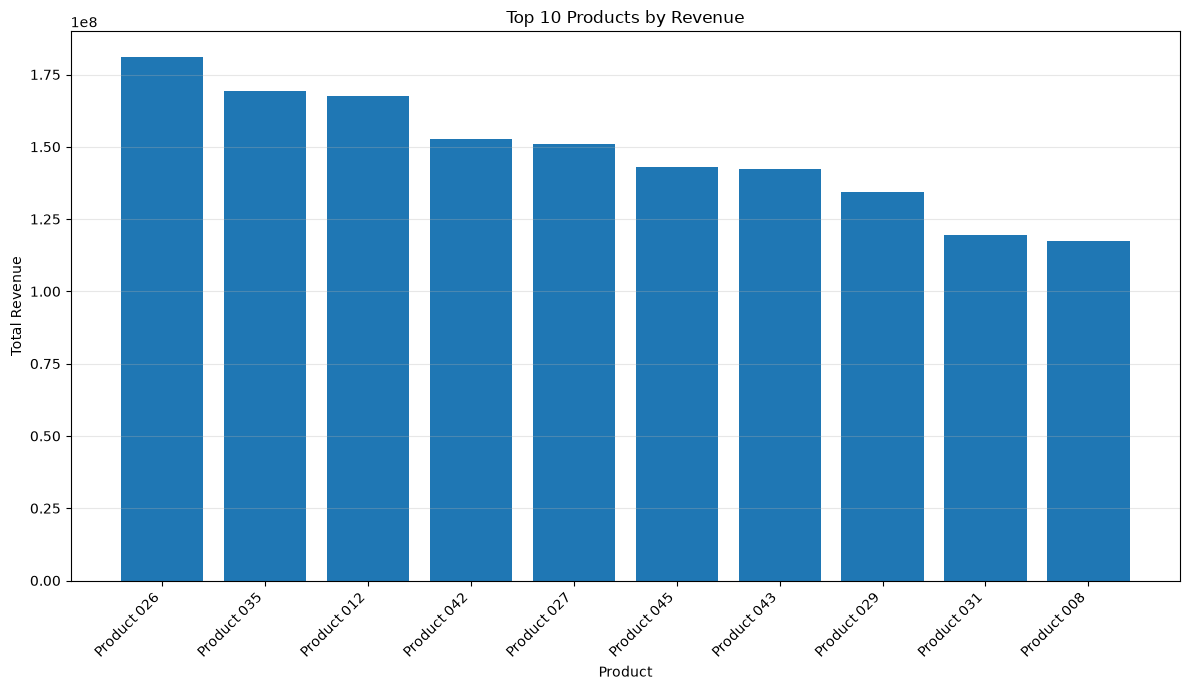

In [21]:

# CELL 16: TOP 10 PRODUCTS BY REVENUE

print("=" * 70)
print("TOP 10 PRODUCTS BY REVENUE")
print("=" * 70)

# Aggregate revenue by SKU
top_products_revenue = (
    sales_with_products
    .groupby(
        ["SKU", "Product_Name"],
        as_index=False
    )
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Units_Sold=("Units_Sold", "sum"),
        Average_Price=("Price", "mean")
    )
    .sort_values(
        "Total_Revenue",
        ascending=False
    )
    .head(10)
)

# Display results
print("\nTop 10 Products by Revenue:")
display(top_products_revenue)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

plt.bar(
    top_products_revenue["Product_Name"].astype(str),
    top_products_revenue["Total_Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

# Top Products by Gross Margin

TOP 10 PRODUCTS BY GROSS MARGIN

Top 10 Products by Estimated Gross Margin:


,SKU,Product_Name,Units_Sold,Revenue,Gross_Margin_Per_Unit,Total_Gross_Margin
34,SKU035,Product 035,15562,1.691619e+08,9732.58,1.514584e+08
25,SKU026,Product 026,16535,1.808853e+08,9140.25,1.511340e+08
26,SKU027,Product 027,17717,1.508886e+08,8209.54,1.454484e+08
11,SKU012,Product 012,19067,1.673962e+08,7522.48,1.434311e+08
42,SKU043,Product 043,16276,1.423462e+08,6140.16,9.993724e+07
7,SKU008,Product 008,11944,1.175605e+08,7067.49,8.441410e+07
41,SKU042,Product 042,16616,1.528478e+08,4614.97,7.668234e+07
44,SKU045,Product 045,18612,1.428802e+08,4042.22,7.523380e+07
28,SKU029,Product 029,11530,1.342374e+08,6239.86,7.194559e+07
48,SKU049,Product 049,18373,9.596898e+07,3160.34,5.806493e+07


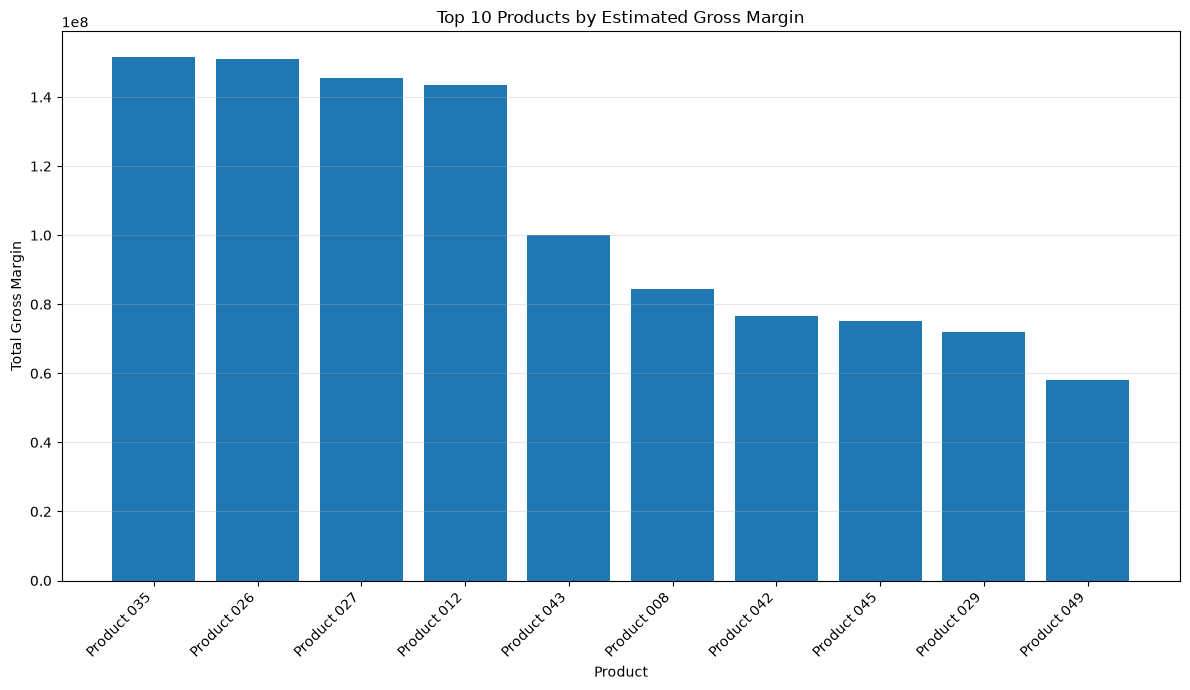

In [23]:
# ============================================================
# CELL 17: TOP 10 PRODUCTS BY GROSS MARGIN
# ============================================================

print("=" * 70)
print("TOP 10 PRODUCTS BY GROSS MARGIN")
print("=" * 70)

# ------------------------------------------------------------
# 1. Merge sales with product master margin information
# ------------------------------------------------------------

margin_data = sales_df.merge(
    products_df[
        [
            "SKU",
            "Product_Name",
            "Category",
            "Subcategory",
            "Gross_Margin_Per_Unit"
        ]
    ],
    on="SKU",
    how="left"
)

# ------------------------------------------------------------
# 2. Calculate estimated gross margin
# ------------------------------------------------------------

margin_data["Estimated_Gross_Margin"] = (
    margin_data["Units_Sold"]
    * margin_data["Gross_Margin_Per_Unit"]
)

# ------------------------------------------------------------
# 3. Aggregate by product
# ------------------------------------------------------------

top_margin_products = (
    margin_data
    .groupby(
        ["SKU", "Product_Name"],
        as_index=False
    )
    .agg(
        Units_Sold=("Units_Sold", "sum"),
        Revenue=("Revenue", "sum"),
        Gross_Margin_Per_Unit=("Gross_Margin_Per_Unit", "first"),
        Total_Gross_Margin=("Estimated_Gross_Margin", "sum")
    )
    .sort_values(
        "Total_Gross_Margin",
        ascending=False
    )
    .head(10)
)

# ------------------------------------------------------------
# 4. Display results
# ------------------------------------------------------------

print("\nTop 10 Products by Estimated Gross Margin:")
display(top_margin_products)

# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

plt.bar(
    top_margin_products["Product_Name"].astype(str),
    top_margin_products["Total_Gross_Margin"]
)

plt.title("Top 10 Products by Estimated Gross Margin")
plt.xlabel("Product")
plt.ylabel("Total Gross Margin")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

# Price vs Demand Analysis

PRICE VS DEMAND ANALYSIS

Price-Demand Correlation: 0.0987

Price vs Demand by SKU:


,SKU,Average_Price,Total_Units_Sold,Average_Units_Sold,Total_Revenue,Product_Name,Category,Subcategory
11,SKU012,8779.37,19067,26.083447,1.673962e+08,Product 012,Home Decor,Table
44,SKU045,7676.78,18612,25.461012,1.428802e+08,Product 045,Storage,Lamp
17,SKU018,5575.41,18450,25.239398,1.028663e+08,Product 018,Kitchen,Rug
48,SKU049,5223.37,18373,25.134063,9.596898e+07,Product 049,Lighting,Organizer
36,SKU037,2747.42,18155,24.835841,4.987941e+07,Product 037,Home Decor,Cabinet
6,SKU007,5114.09,18129,24.800274,9.271334e+07,Product 007,Home Decor,Cabinet
26,SKU027,8516.60,17717,24.236662,1.508886e+08,Product 027,Home Decor,Cabinet
41,SKU042,9198.83,16616,22.730506,1.528478e+08,Product 042,Home Decor,Table
25,SKU026,10939.54,16535,22.619699,1.808853e+08,Product 026,Furniture,Shelf
42,SKU043,8745.77,16276,22.265390,1.423462e+08,Product 043,Kitchen,Cushion


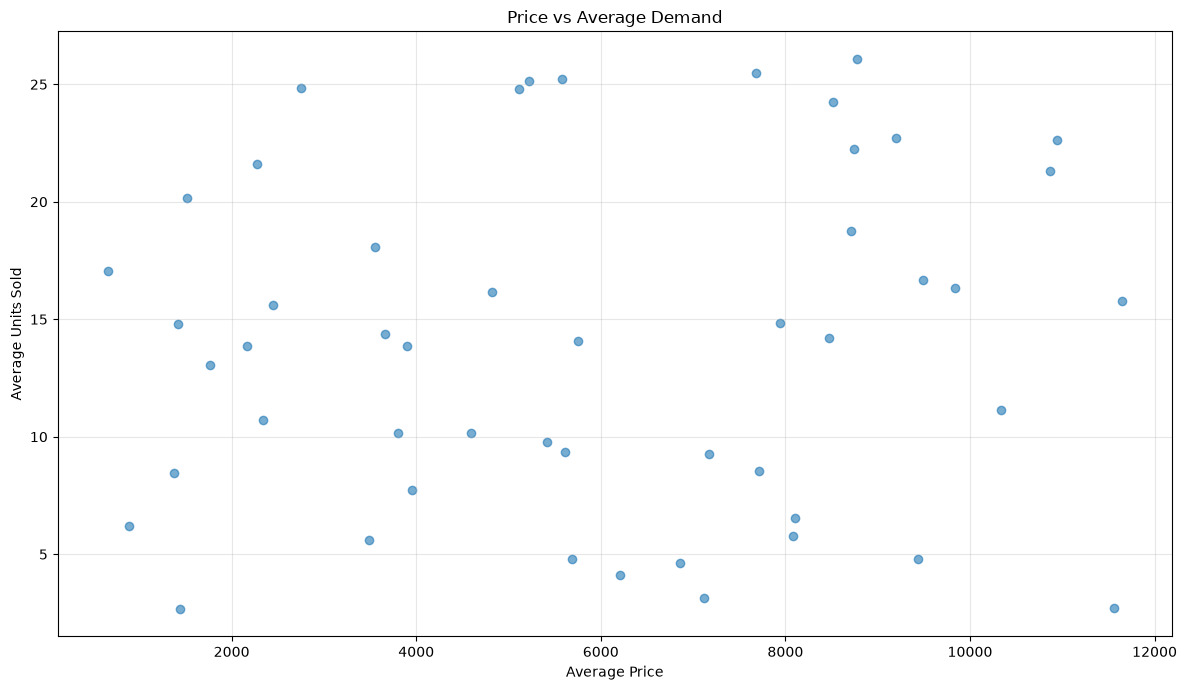


Price Statistics:
Minimum Average Price : 663.46
Maximum Average Price : 11,642.45
Average Price : 5,892.66

Demand Statistics:
Minimum Average Demand : 2.67
Maximum Average Demand : 26.08
Average Demand : 14.00


In [25]:
# ============================================================
# CELL 18: PRICE VS DEMAND ANALYSIS
# ============================================================

print("=" * 70)
print("PRICE VS DEMAND ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Create price-demand dataset
# ------------------------------------------------------------

price_demand = (
    sales_df
    .groupby("SKU", as_index=False)
    .agg(
        Average_Price=("Price", "mean"),
        Total_Units_Sold=("Units_Sold", "sum"),
        Average_Units_Sold=("Units_Sold", "mean"),
        Total_Revenue=("Revenue", "sum")
    )
)

# ------------------------------------------------------------
# 2. Add product information
# ------------------------------------------------------------

price_demand = price_demand.merge(
    products_df[
        ["SKU", "Product_Name", "Category", "Subcategory"]
    ],
    on="SKU",
    how="left"
)

# ------------------------------------------------------------
# 3. Correlation between price and demand
# ------------------------------------------------------------

price_demand_correlation = price_demand[
    ["Average_Price", "Average_Units_Sold"]
].corr().iloc[0, 1]

print(f"\nPrice-Demand Correlation: {price_demand_correlation:.4f}")

# ------------------------------------------------------------
# 4. Display price-demand data
# ------------------------------------------------------------

print("\nPrice vs Demand by SKU:")
display(
    price_demand.sort_values(
        "Average_Units_Sold",
        ascending=False
    ).head(20)
)

# ------------------------------------------------------------
# 5. Plot Price vs Demand
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

plt.scatter(
    price_demand["Average_Price"],
    price_demand["Average_Units_Sold"],
    alpha=0.6
)

plt.title("Price vs Average Demand")
plt.xlabel("Average Price")
plt.ylabel("Average Units Sold")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 6. Price statistics
# ------------------------------------------------------------

print("\nPrice Statistics:")
print(
    f"Minimum Average Price : "
    f"{price_demand['Average_Price'].min():,.2f}"
)

print(
    f"Maximum Average Price : "
    f"{price_demand['Average_Price'].max():,.2f}"
)

print(
    f"Average Price : "
    f"{price_demand['Average_Price'].mean():,.2f}"
)

# ------------------------------------------------------------
# 7. Demand statistics
# ------------------------------------------------------------

print("\nDemand Statistics:")
print(
    f"Minimum Average Demand : "
    f"{price_demand['Average_Units_Sold'].min():,.2f}"
)

print(
    f"Maximum Average Demand : "
    f"{price_demand['Average_Units_Sold'].max():,.2f}"
)

print(
    f"Average Demand : "
    f"{price_demand['Average_Units_Sold'].mean():,.2f}"
)

# Promotion Impact by SKU

PROMOTION IMPACT BY SKU

Top SKUs Benefiting from Promotions:


,SKU,Product_Name,Category,Subcategory,Promotion,No Promotion,Promotion_Uplift,Promotion_Uplift_Percent
23,SKU024,Product 024,Lighting,Cookware,18.546667,12.445122,6.101545,49.027601
33,SKU034,Product 034,Lighting,Cookware,28.160000,19.236280,8.923720,46.390047
18,SKU019,Product 019,Lighting,Organizer,22.533333,15.416159,7.117175,46.166980
11,SKU012,Product 012,Home Decor,Table,36.226667,24.923780,11.302886,45.349806
47,SKU048,Product 048,Kitchen,Rug,11.693333,8.076220,3.617114,44.787215
2,SKU003,Product 003,Kitchen,Cushion,7.973333,5.512195,2.461138,44.648968
37,SKU038,Product 038,Kitchen,Rug,10.600000,7.387195,3.212805,43.491539
32,SKU033,Product 033,Kitchen,Cushion,24.800000,17.323171,7.476829,43.160859
9,SKU010,Product 010,Storage,Sofa,23.360000,16.324695,7.035305,43.096087
0,SKU001,Product 001,Furniture,Chair,19.626667,13.765244,5.861423,42.581322



SKUs with Lowest Promotion Impact:


,SKU,Product_Name,Category,Subcategory,Promotion,No Promotion,Promotion_Uplift,Promotion_Uplift_Percent
22,SKU023,Product 023,Kitchen,Cushion,18.560000,14.387195,4.172805,29.003602
38,SKU039,Product 039,Lighting,Organizer,3.973333,3.051829,0.921504,30.195138
31,SKU032,Product 032,Home Decor,Table,11.826667,9.045732,2.780935,30.743063
8,SKU009,Product 009,Lighting,Organizer,13.600000,10.381098,3.218902,31.007342
27,SKU028,Product 028,Kitchen,Rug,7.133333,5.435976,1.697358,31.224528
20,SKU021,Product 021,Furniture,Chair,10.893333,8.263720,2.629614,31.821189
48,SKU049,Product 049,Lighting,Organizer,32.106667,24.336890,7.769776,31.925921
3,SKU004,Product 004,Lighting,Cookware,5.933333,4.474085,1.459248,32.615559
43,SKU044,Product 044,Lighting,Cookware,12.546667,9.457317,3.089350,32.666237
10,SKU011,Product 011,Furniture,Chair,3.440000,2.580793,0.859207,33.292380


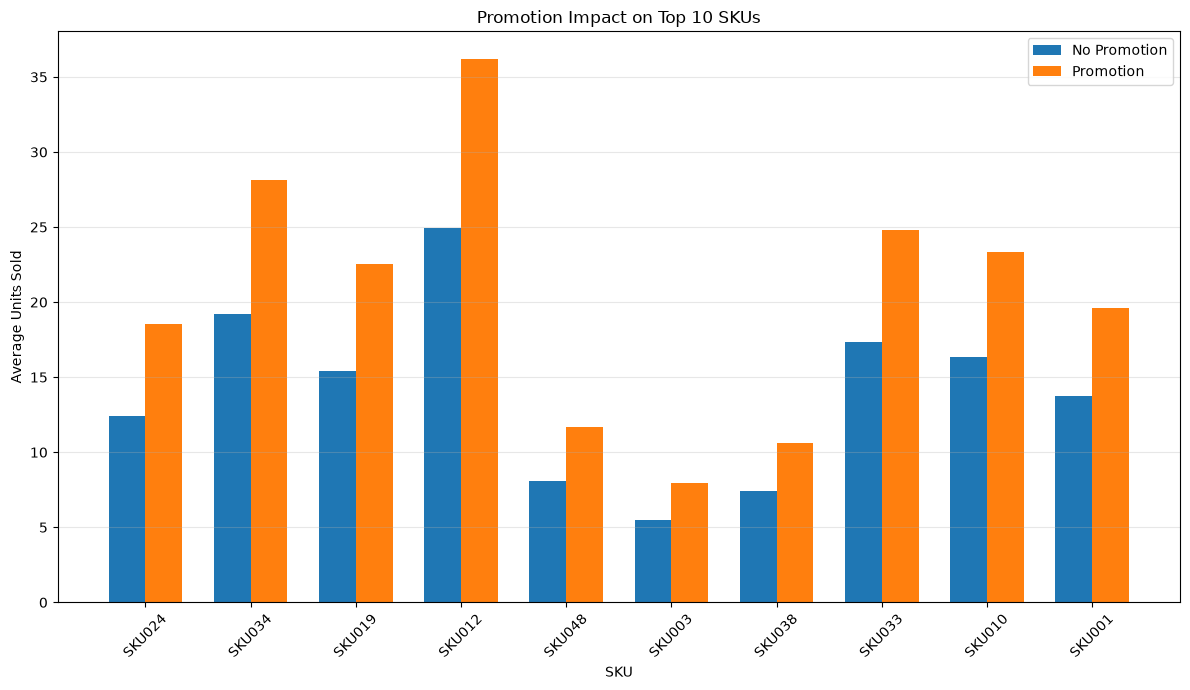

In [27]:
# ============================================================
# CELL 19: PROMOTION IMPACT BY SKU
# ============================================================

print("=" * 70)
print("PROMOTION IMPACT BY SKU")
print("=" * 70)

# ------------------------------------------------------------
# 1. Prepare promotion data
# ------------------------------------------------------------

promotion_sku = sales_df.copy()

# Convert Promotion into a clean binary indicator
promotion_sku["Promotion_Flag"] = (
    promotion_sku["Promotion"]
    .fillna(0)
    .astype(int)
)

# Create readable labels
promotion_sku["Promotion_Status"] = np.where(
    promotion_sku["Promotion_Flag"] == 1,
    "Promotion",
    "No Promotion"
)

# ------------------------------------------------------------
# 2. Calculate average demand by SKU and promotion status
# ------------------------------------------------------------

sku_promotion = (
    promotion_sku
    .groupby(
        ["SKU", "Promotion_Status"],
        as_index=False
    )
    .agg(
        Average_Units_Sold=("Units_Sold", "mean"),
        Total_Units_Sold=("Units_Sold", "sum"),
        Average_Revenue=("Revenue", "mean"),
        Total_Revenue=("Revenue", "sum"),
        Records=("Units_Sold", "count")
    )
)

# ------------------------------------------------------------
# 3. Convert promotion statuses into columns
# ------------------------------------------------------------

sku_pivot = (
    sku_promotion
    .pivot(
        index="SKU",
        columns="Promotion_Status",
        values="Average_Units_Sold"
    )
    .reset_index()
)

# Make sure both columns exist
if "Promotion" not in sku_pivot.columns:
    sku_pivot["Promotion"] = np.nan

if "No Promotion" not in sku_pivot.columns:
    sku_pivot["No Promotion"] = np.nan

# ------------------------------------------------------------
# 4. Calculate promotion uplift
# ------------------------------------------------------------

sku_pivot["Promotion_Uplift"] = (
    sku_pivot["Promotion"]
    - sku_pivot["No Promotion"]
)

sku_pivot["Promotion_Uplift_Percent"] = np.where(
    sku_pivot["No Promotion"] > 0,
    (
        sku_pivot["Promotion_Uplift"]
        / sku_pivot["No Promotion"]
    ) * 100,
    np.nan
)

# ------------------------------------------------------------
# 5. Add product information
# ------------------------------------------------------------

sku_pivot = sku_pivot.merge(
    products_df[
        ["SKU", "Product_Name", "Category", "Subcategory"]
    ],
    on="SKU",
    how="left"
)

# ------------------------------------------------------------
# 6. Sort by promotion uplift
# ------------------------------------------------------------

promotion_impact = (
    sku_pivot[
        [
            "SKU",
            "Product_Name",
            "Category",
            "Subcategory",
            "Promotion",
            "No Promotion",
            "Promotion_Uplift",
            "Promotion_Uplift_Percent"
        ]
    ]
    .sort_values(
        "Promotion_Uplift_Percent",
        ascending=False,
        na_position="last"
    )
)

print("\nTop SKUs Benefiting from Promotions:")
display(promotion_impact.head(20))

# ------------------------------------------------------------
# 7. Most negatively affected / lowest uplift SKUs
# ------------------------------------------------------------

print("\nSKUs with Lowest Promotion Impact:")
display(
    promotion_impact
    .sort_values(
        "Promotion_Uplift_Percent",
        ascending=True,
        na_position="last"
    )
    .head(20)
)

# ------------------------------------------------------------
# 8. Plot top promotion-sensitive SKUs
# ------------------------------------------------------------

plot_data = (
    promotion_impact
    .dropna(subset=["Promotion", "No Promotion"])
    .sort_values(
        "Promotion_Uplift_Percent",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12, 7))

x = np.arange(len(plot_data))
width = 0.35

plt.bar(
    x - width / 2,
    plot_data["No Promotion"],
    width,
    label="No Promotion"
)

plt.bar(
    x + width / 2,
    plot_data["Promotion"],
    width,
    label="Promotion"
)

plt.xticks(
    x,
    plot_data["SKU"].astype(str),
    rotation=45
)

plt.title("Promotion Impact on Top 10 SKUs")
plt.xlabel("SKU")
plt.ylabel("Average Units Sold")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

# SKU Sales Volatility Analysis

SKU SALES VOLATILITY ANALYSIS

Most Volatile SKUs:


,SKU,Product_Name,Category,Average_Demand,Demand_Std,Minimum_Demand,Maximum_Demand,Volatility_Percent,Volatility_Level
10,SKU011,Product 011,Furniture,2.668947,1.736744,0,9,65.072277,High
24,SKU025,Product 025,Storage,2.703146,1.696323,0,11,62.753638,High
38,SKU039,Product 039,Lighting,3.146375,1.829491,0,9,58.146004,Moderate
14,SKU015,Product 015,Storage,4.095759,2.196291,0,12,53.623539,Moderate
3,SKU004,Product 004,Lighting,4.623803,2.363984,0,16,51.126393,Moderate
35,SKU036,Product 036,Furniture,4.798906,2.338317,0,15,48.726040,Moderate
2,SKU003,Product 003,Kitchen,5.764706,2.762154,0,17,47.914909,Moderate
29,SKU030,Product 030,Storage,4.778386,2.279780,0,14,47.710247,Moderate
27,SKU028,Product 028,Kitchen,5.610123,2.541137,0,14,45.295564,Moderate
49,SKU050,Product 050,Storage,6.206566,2.806501,0,15,45.218261,Moderate



Volatility Level Summary:


,Volatility_Level,SKU_Count
0,Moderate,32
1,Low,16
2,High,2


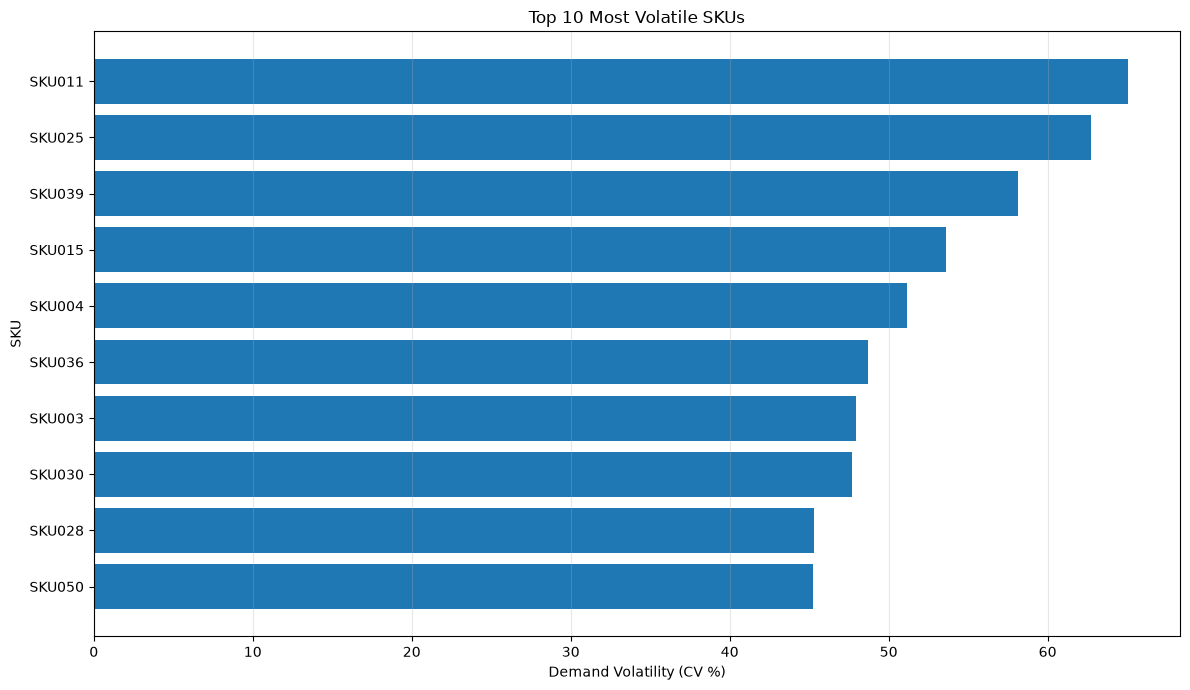

In [29]:
# ============================================================
# CELL 20: SKU SALES VOLATILITY ANALYSIS
# ============================================================

print("=" * 70)
print("SKU SALES VOLATILITY ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Calculate demand statistics for each SKU
# ------------------------------------------------------------

sku_volatility = (
    sales_df
    .groupby("SKU", as_index=False)
    .agg(
        Average_Demand=("Units_Sold", "mean"),
        Demand_Std=("Units_Sold", "std"),
        Minimum_Demand=("Units_Sold", "min"),
        Maximum_Demand=("Units_Sold", "max"),
        Total_Units_Sold=("Units_Sold", "sum"),
        Sales_Records=("Units_Sold", "count")
    )
)

# ------------------------------------------------------------
# 2. Calculate Coefficient of Variation
# ------------------------------------------------------------

sku_volatility["Coefficient_of_Variation"] = np.where(
    sku_volatility["Average_Demand"] > 0,
    sku_volatility["Demand_Std"]
    / sku_volatility["Average_Demand"],
    np.nan
)

# Convert CV to percentage
sku_volatility["Volatility_Percent"] = (
    sku_volatility["Coefficient_of_Variation"] * 100
)

# ------------------------------------------------------------
# 3. Classify volatility
# ------------------------------------------------------------

sku_volatility["Volatility_Level"] = np.select(
    [
        sku_volatility["Coefficient_of_Variation"] <= 0.30,
        sku_volatility["Coefficient_of_Variation"] <= 0.60,
        sku_volatility["Coefficient_of_Variation"] <= 1.00,
        sku_volatility["Coefficient_of_Variation"] > 1.00
    ],
    [
        "Low",
        "Moderate",
        "High",
        "Very High"
    ],
    default="Unknown"
)

# ------------------------------------------------------------
# 4. Add product information
# ------------------------------------------------------------

sku_volatility = sku_volatility.merge(
    products_df[
        ["SKU", "Product_Name", "Category", "Subcategory"]
    ],
    on="SKU",
    how="left"
)

# ------------------------------------------------------------
# 5. Display most volatile SKUs
# ------------------------------------------------------------

print("\nMost Volatile SKUs:")

most_volatile = (
    sku_volatility
    .sort_values(
        "Coefficient_of_Variation",
        ascending=False,
        na_position="last"
    )
)

display(
    most_volatile[
        [
            "SKU",
            "Product_Name",
            "Category",
            "Average_Demand",
            "Demand_Std",
            "Minimum_Demand",
            "Maximum_Demand",
            "Volatility_Percent",
            "Volatility_Level"
        ]
    ].head(20)
)

# ------------------------------------------------------------
# 6. Volatility summary
# ------------------------------------------------------------

print("\nVolatility Level Summary:")

volatility_summary = (
    sku_volatility["Volatility_Level"]
    .value_counts()
    .rename_axis("Volatility_Level")
    .reset_index(name="SKU_Count")
)

display(volatility_summary)

# ------------------------------------------------------------
# 7. Plot top volatile SKUs
# ------------------------------------------------------------

plot_data = (
    most_volatile
    .dropna(subset=["Volatility_Percent"])
    .head(10)
    .sort_values("Volatility_Percent")
)

plt.figure(figsize=(12, 7))

plt.barh(
    plot_data["SKU"].astype(str),
    plot_data["Volatility_Percent"]
)

plt.title("Top 10 Most Volatile SKUs")
plt.xlabel("Demand Volatility (CV %)")
plt.ylabel("SKU")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

# Correlation Analysis

CORRELATION ANALYSIS

Sales Variable Correlation Matrix:


,Units_Sold,Revenue,Price,Promotion_Flag
Units_Sold,1.000000,0.748263,8.249497e-02,1.840966e-01
Revenue,0.748263,1.000000,6.340407e-01,1.220092e-01
Price,0.082495,0.634041,1.000000e+00,2.069080e-16
Promotion_Flag,0.184097,0.122009,2.069080e-16,1.000000e+00



Sales + Product Correlation Matrix:


,Units_Sold,Revenue,Price,Promotion,Cost_Price,Selling_Price,Gross_Margin_Per_Unit,Estimated_Gross_Margin
Units_Sold,1.000000,0.748263,8.249497e-02,1.840966e-01,-8.820629e-02,8.249497e-02,1.163168e-01,0.426056
Revenue,0.748263,1.000000,6.340407e-01,1.220092e-01,-9.813873e-02,6.340407e-01,5.836629e-01,0.835097
Price,0.082495,0.634041,1.000000e+00,2.069080e-16,-1.314391e-02,1.000000e+00,8.447352e-01,0.683313
Promotion,0.184097,0.122009,2.069080e-16,1.000000e+00,-2.074719e-16,2.071366e-16,-7.803527e-17,0.052360
Cost_Price,-0.088206,-0.098139,-1.314391e-02,-2.074719e-16,1.000000e+00,-1.314391e-02,-5.462413e-01,-0.457690
Selling_Price,0.082495,0.634041,1.000000e+00,2.071366e-16,-1.314391e-02,1.000000e+00,8.447352e-01,0.683313
Gross_Margin_Per_Unit,0.116317,0.583663,8.447352e-01,-7.803527e-17,-5.462413e-01,8.447352e-01,1.000000e+00,0.817381
Estimated_Gross_Margin,0.426056,0.835097,6.833131e-01,5.235958e-02,-4.576899e-01,6.833131e-01,8.173812e-01,1.000000


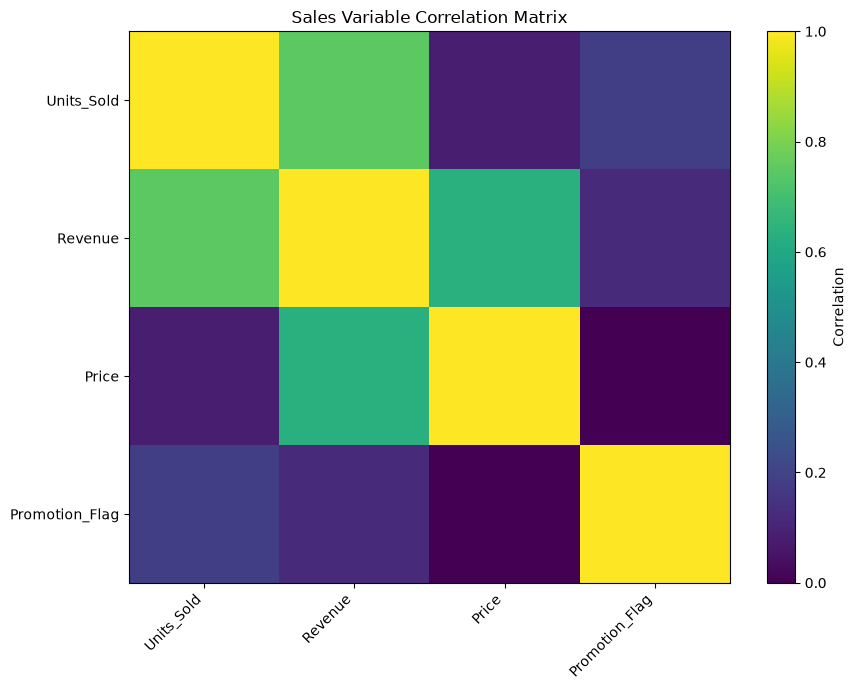


Correlation with Units Sold:


,Correlation
Revenue,0.748263
Promotion_Flag,0.184097
Price,0.082495


In [31]:
# ============================================================
# CELL 21: CORRELATION ANALYSIS
# ============================================================

print("=" * 70)
print("CORRELATION ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Prepare sales data for correlation
# ------------------------------------------------------------

correlation_data = sales_df.copy()

# Create a clean numeric promotion variable
correlation_data["Promotion_Flag"] = (
    correlation_data["Promotion"]
    .fillna(0)
    .astype(int)
)

# ------------------------------------------------------------
# 2. Select numerical sales variables
# ------------------------------------------------------------

sales_corr = correlation_data[
    [
        "Units_Sold",
        "Revenue",
        "Price",
        "Promotion_Flag"
    ]
].corr()

print("\nSales Variable Correlation Matrix:")
display(sales_corr)

# ------------------------------------------------------------
# 3. Add product-level information
# ------------------------------------------------------------

product_corr_data = sales_df.merge(
    products_df[
        [
            "SKU",
            "Cost_Price",
            "Selling_Price",
            "Gross_Margin_Per_Unit"
        ]
    ],
    on="SKU",
    how="left"
)

# Calculate estimated gross margin
product_corr_data["Estimated_Gross_Margin"] = (
    product_corr_data["Units_Sold"]
    * product_corr_data["Gross_Margin_Per_Unit"]
)

# ------------------------------------------------------------
# 4. Product-level correlation matrix
# ------------------------------------------------------------

product_corr = product_corr_data[
    [
        "Units_Sold",
        "Revenue",
        "Price",
        "Promotion",
        "Cost_Price",
        "Selling_Price",
        "Gross_Margin_Per_Unit",
        "Estimated_Gross_Margin"
    ]
].corr()

print("\nSales + Product Correlation Matrix:")
display(product_corr)

# ------------------------------------------------------------
# 5. Visualize sales correlations
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

plt.imshow(
    sales_corr,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(sales_corr.columns)),
    sales_corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(sales_corr.index)),
    sales_corr.index
)

plt.title("Sales Variable Correlation Matrix")

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 6. Find strongest relationships with Units Sold
# ------------------------------------------------------------

units_correlation = (
    sales_corr["Units_Sold"]
    .drop("Units_Sold")
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

print("\nCorrelation with Units Sold:")
display(
    units_correlation
    .rename("Correlation")
    .to_frame()
)

# EDA Summary & Key Business Insights

In [32]:
# ============================================================
# CELL 22: EDA SUMMARY & KEY BUSINESS INSIGHTS
# ============================================================

print("=" * 80)
print("FORESIGHT - EDA SUMMARY & KEY BUSINESS INSIGHTS")
print("=" * 80)

# ------------------------------------------------------------
# 1. SALES OVERVIEW
# ------------------------------------------------------------

total_units = sales_df["Units_Sold"].sum()
total_revenue = sales_df["Revenue"].sum()
unique_skus = sales_df["SKU"].nunique()
sales_records = len(sales_df)

print("\n" + "-" * 80)
print("1. SALES OVERVIEW")
print("-" * 80)

print(f"Total Sales Records : {sales_records:,}")
print(f"Unique SKUs        : {unique_skus:,}")
print(f"Total Units Sold   : {total_units:,.0f}")
print(f"Total Revenue      : {total_revenue:,.2f}")


# ------------------------------------------------------------
# 2. TOP PERFORMING SKU
# ------------------------------------------------------------

top_sku = (
    sales_df.groupby("SKU")["Units_Sold"]
    .sum()
    .sort_values(ascending=False)
)

print("\n" + "-" * 80)
print("2. TOP PERFORMING SKUs")
print("-" * 80)

print(f"Top SKU by Units Sold : {top_sku.index[0]}")
print(f"Units Sold            : {top_sku.iloc[0]:,.0f}")


# ------------------------------------------------------------
# 3. LOW PERFORMING SKU
# ------------------------------------------------------------

bottom_sku = top_sku.sort_values(ascending=True)

print(f"\nLowest SKU by Units Sold : {bottom_sku.index[0]}")
print(f"Units Sold               : {bottom_sku.iloc[0]:,.0f}")


# ------------------------------------------------------------
# 4. TOP REVENUE PRODUCT
# ------------------------------------------------------------

if "top_products_revenue" in globals():

    top_revenue_product = top_products_revenue.iloc[0]

    print("\n" + "-" * 80)
    print("3. TOP REVENUE PRODUCT")
    print("-" * 80)

    print(f"Product : {top_revenue_product['Product_Name']}")
    print(f"SKU     : {top_revenue_product['SKU']}")
    print(
        f"Revenue : "
        f"{top_revenue_product['Total_Revenue']:,.2f}"
    )


# ------------------------------------------------------------
# 5. TOP GROSS MARGIN PRODUCT
# ------------------------------------------------------------

if "top_margin_products" in globals():

    top_margin_product = top_margin_products.iloc[0]

    print("\n" + "-" * 80)
    print("4. TOP GROSS MARGIN PRODUCT")
    print("-" * 80)

    print(f"Product : {top_margin_product['Product_Name']}")
    print(f"SKU     : {top_margin_product['SKU']}")
    print(
        f"Gross Margin : "
        f"{top_margin_product['Total_Gross_Margin']:,.2f}"
    )


# ------------------------------------------------------------
# 6. INVENTORY OVERVIEW
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("5. INVENTORY OVERVIEW")
print("-" * 80)

total_current_stock = inventory_df["Current_Stock"].sum()
total_on_order = inventory_df["On_Order"].sum()
total_inventory_value = inventory_df["Inventory_Value"].sum()

print(f"Total Current Stock  : {total_current_stock:,.0f}")
print(f"Total On-Order Stock : {total_on_order:,.0f}")
print(f"Total Inventory Value: {total_inventory_value:,.2f}")


# ------------------------------------------------------------
# 7. STOCKOUT / DEMAND RISK
# ------------------------------------------------------------

if "Demand_Risk" in inventory_demand.columns:

    demand_risk_counts = (
        inventory_demand["Demand_Risk"]
        .value_counts()
    )

    stockout_risk_count = demand_risk_counts.get(
        "Stockout Risk", 0
    )

    high_stockout_count = demand_risk_counts.get(
        "High Stockout Risk", 0
    )

    reorder_count = demand_risk_counts.get(
        "Reorder Required", 0
    )

    print("\n" + "-" * 80)
    print("6. STOCKOUT & DEMAND RISK")
    print("-" * 80)

    print(f"Stockout Risk       : {stockout_risk_count:,}")
    print(f"High Stockout Risk  : {high_stockout_count:,}")
    print(f"Reorder Required    : {reorder_count:,}")


# ------------------------------------------------------------
# 8. OVERSTOCK RISK
# ------------------------------------------------------------

if "Overstock_Risk" in inventory_demand.columns:

    overstock_counts = (
        inventory_demand["Overstock_Risk"]
        .value_counts()
    )

    high_overstock = overstock_counts.get(
        "High Overstock Risk", 0
    )

    moderate_overstock = overstock_counts.get(
        "Moderate Overstock Risk", 0
    )

    no_demand = overstock_counts.get(
        "No Demand", 0
    )

    print("\n" + "-" * 80)
    print("7. OVERSTOCK RISK")
    print("-" * 80)

    print(f"High Overstock Risk      : {high_overstock:,}")
    print(f"Moderate Overstock Risk  : {moderate_overstock:,}")
    print(f"No Demand                : {no_demand:,}")


# ------------------------------------------------------------
# 9. COMBINED INVENTORY RISK
# ------------------------------------------------------------

if "Combined_Risk" in inventory_demand.columns:

    combined_risk = (
        inventory_demand["Combined_Risk"]
        .value_counts()
    )

    print("\n" + "-" * 80)
    print("8. COMBINED INVENTORY RISK")
    print("-" * 80)

    for risk, count in combined_risk.items():
        print(f"{risk:<30}: {count:,}")


# ------------------------------------------------------------
# 10. MOST VOLATILE SKU
# ------------------------------------------------------------

if "sku_volatility" in globals():

    volatility_data = (
        sku_volatility
        .dropna(subset=["Coefficient_of_Variation"])
        .sort_values(
            "Coefficient_of_Variation",
            ascending=False
        )
    )

    if len(volatility_data) > 0:

        volatile_sku = volatility_data.iloc[0]

        print("\n" + "-" * 80)
        print("9. DEMAND VOLATILITY")
        print("-" * 80)

        print(f"Most Volatile SKU : {volatile_sku['SKU']}")
        print(
            f"Volatility (CV)  : "
            f"{volatile_sku['Volatility_Percent']:.2f}%"
        )
        print(
            f"Volatility Level : "
            f"{volatile_sku['Volatility_Level']}"
        )


# ------------------------------------------------------------
# 11. PROMOTION IMPACT
# ------------------------------------------------------------

if "promotion_impact" in globals():

    promotion_data = (
        promotion_impact
        .dropna(subset=["Promotion_Uplift_Percent"])
        .sort_values(
            "Promotion_Uplift_Percent",
            ascending=False
        )
    )

    if len(promotion_data) > 0:

        best_promotion = promotion_data.iloc[0]

        print("\n" + "-" * 80)
        print("10. PROMOTION IMPACT")
        print("-" * 80)

        print(
            f"Highest Promotion Uplift SKU : "
            f"{best_promotion['SKU']}"
        )

        print(
            f"Promotion Uplift             : "
            f"{best_promotion['Promotion_Uplift_Percent']:.2f}%"
        )


# ------------------------------------------------------------
# 12. PRICE-DEMAND CORRELATION
# ------------------------------------------------------------

if "price_demand_correlation" in globals():

    print("\n" + "-" * 80)
    print("11. PRICE VS DEMAND")
    print("-" * 80)

    print(
        f"Price-Demand Correlation : "
        f"{price_demand_correlation:.4f}"
    )


# ------------------------------------------------------------
# 13. CORRELATION WITH UNITS SOLD
# ------------------------------------------------------------

if "units_correlation" in globals():

    print("\n" + "-" * 80)
    print("12. CORRELATION WITH DEMAND")
    print("-" * 80)

    display(
        units_correlation
        .rename("Correlation")
        .to_frame()
    )


# ------------------------------------------------------------
# 14. KEY BUSINESS INSIGHTS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("KEY BUSINESS INSIGHTS FOR FORESIGHT")
print("=" * 80)

print("""
1. DEMAND FORECASTING
   • Historical sales data provides the foundation for SKU-level
     demand forecasting.
   • Monthly, seasonal and SKU-level demand patterns should be
     considered as forecasting features.

2. STOCKOUT PREVENTION
   • SKUs with high demand and low Days of Stock require priority.
   • Lead Time, Safety Stock and Reorder Point should be included
     in the replenishment decision.

3. OVERSTOCK PREVENTION
   • SKUs with excessive Days of Stock may create unnecessary
     inventory holding costs.
   • Low-demand products should be monitored for overstock risk.

4. PROMOTION INTELLIGENCE
   • Promotion uplift can identify SKUs that respond strongly
     to promotional campaigns.
   • Promotion information can be used as an external demand
     forecasting feature.

5. DEMAND VOLATILITY
   • High-volatility SKUs are harder to forecast accurately.
   • These products may require additional safety-stock consideration.

6. PRODUCT PROFITABILITY
   • Revenue alone does not identify the most profitable products.
   • Gross margin should be considered alongside sales volume
     when prioritizing inventory.

7. PRICE & DEMAND
   • Price-demand correlation provides an initial indication of
     price sensitivity.
   • Further analysis should control for promotion, seasonality
     and product category.

8. FORESIGHT MODELING PRIORITIES
   • SKU-level demand forecasting
   • Stockout risk prediction
   • Overstock risk prediction
   • Inventory recommendation
   • Promotion-aware forecasting
   • Explainable business recommendations
""")

print("\n" + "=" * 80)
print("EDA COMPLETE")
print("=" * 80)

FORESIGHT - EDA SUMMARY & KEY BUSINESS INSIGHTS

--------------------------------------------------------------------------------
1. SALES OVERVIEW
--------------------------------------------------------------------------------
Total Sales Records : 36,550
Unique SKUs        : 50
Total Units Sold   : 511,810
Total Revenue      : 3,096,056,707.22

--------------------------------------------------------------------------------
2. TOP PERFORMING SKUs
--------------------------------------------------------------------------------
Top SKU by Units Sold : SKU012
Units Sold            : 19,067

Lowest SKU by Units Sold : SKU011
Units Sold               : 1,951

--------------------------------------------------------------------------------
3. TOP REVENUE PRODUCT
--------------------------------------------------------------------------------
Product : Product 026
SKU     : SKU026
Revenue : 180,885,293.90

--------------------------------------------------------------------------------
4. 

,Correlation
Revenue,0.748263
Promotion_Flag,0.184097
Price,0.082495



KEY BUSINESS INSIGHTS FOR FORESIGHT

1. DEMAND FORECASTING
   • Historical sales data provides the foundation for SKU-level
     demand forecasting.
   • Monthly, seasonal and SKU-level demand patterns should be
     considered as forecasting features.

2. STOCKOUT PREVENTION
   • SKUs with high demand and low Days of Stock require priority.
   • Lead Time, Safety Stock and Reorder Point should be included
     in the replenishment decision.

3. OVERSTOCK PREVENTION
   • SKUs with excessive Days of Stock may create unnecessary
     inventory holding costs.
   • Low-demand products should be monitored for overstock risk.

4. PROMOTION INTELLIGENCE
   • Promotion uplift can identify SKUs that respond strongly
     to promotional campaigns.
   • Promotion information can be used as an external demand
     forecasting feature.

5. DEMAND VOLATILITY
   • High-volatility SKUs are harder to forecast accurately.
   • These products may require additional safety-stock consideration.

6. PRODUC